# Week 05 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

*(F1 special case — Cell F classifier + log-SVR always runs; balanced Voronoi fallback if untrustworthy)*

**F1 outliers are SIGNAL, not noise**: pt4 (0.65, 0.68) Y=-3.6e-3 and pt10 (0.42, 0.46) Y=-6.6e-3 are the only points with non-trivial |Y| (all others have |Y| < 1e-15). They define the sign boundary. Do NOT remove them. (Contrast with F3 where the outlier was distortion.)

In [3]:
# Cell A — setup + data overview [REQUIRED]
import sys
sys.path.append('../src')
import nn_models as nm
from scipy.spatial.distance import cdist
from sklearn.linear_model import Ridge, LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, SVC
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel as C
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score
import warnings; warnings.filterwarnings('ignore', message='R.*score is not well-defined')

X, Y = load_function(1)
D = X.shape[1]
baseline = Y.std()
loo = LeaveOneOut()

quads = {'Q1':0, 'Q2':0, 'Q3':0, 'Q4':0}
for x1, x2 in X:
    if x1>=0.5 and x2>=0.5: quads['Q1']+=1
    elif x1<0.5 and x2>=0.5: quads['Q2']+=1
    elif x1<0.5 and x2<0.5: quads['Q3']+=1
    else: quads['Q4']+=1
print(f"F1: {len(Y)} pts, {D}D  |  Baseline={baseline:.4e}  |  Y range [{Y.min():.2e}, {Y.max():.2e}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"Quadrant coverage: " + ", ".join(f"{k}={v}" for k, v in sorted(quads.items())))
print(f"\nSorted by Y (★ = W4 query):")
for idx in np.argsort(-Y):
    mark = '★' if idx == len(Y)-1 else ' '
    print(f"  {mark} x=({X[idx,0]:.4f}, {X[idx,1]:.4f})  y={Y[idx]:+.4e}")


Function 1: 14 points, 2D, best y = 0.0000
F1: 14 pts, 2D  |  Baseline=1.8793e-03  |  Y range [-6.63e-03, 3.65e-07]
Per-dim correlations: r(x1,Y)=+0.128, r(x2,Y)=+0.023
Quadrant coverage: Q1=7, Q2=1, Q3=4, Q4=2

Sorted by Y (★ = W4 query):
    x=(0.7002, 0.6954)  y=+3.6511e-07
    x=(0.7310, 0.7330)  y=+7.7109e-16
  ★ x=(0.6654, 0.4374)  y=+1.8940e-28
    x=(0.7800, 0.7800)  y=+2.5001e-32
    x=(0.6834, 0.8611)  y=+2.5350e-40
    x=(0.5743, 0.8799)  y=+1.0331e-46
    x=(0.8839, 0.5823)  y=+6.2299e-48
    x=(0.3194, 0.7630)  y=+1.3227e-79
    x=(0.0825, 0.4035)  y=+3.6068e-81
    x=(0.8404, 0.2647)  y=+3.3418e-124
    x=(0.3127, 0.0787)  y=-2.0891e-91
    x=(0.4104, 0.1476)  y=-2.1592e-54
    x=(0.6501, 0.6815)  y=-3.6061e-03
    x=(0.4211, 0.4636)  y=-6.6274e-03


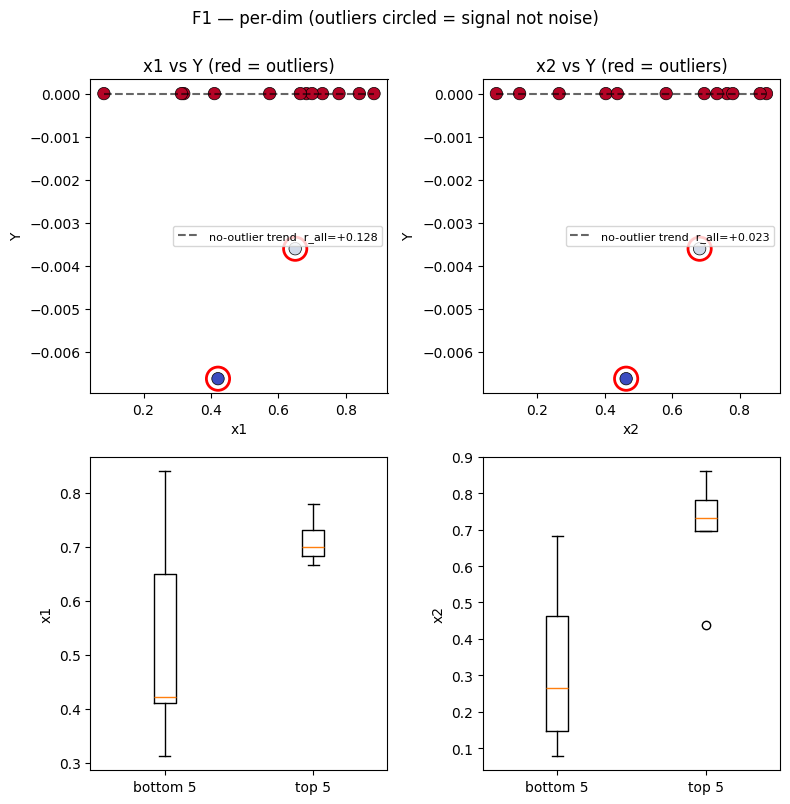

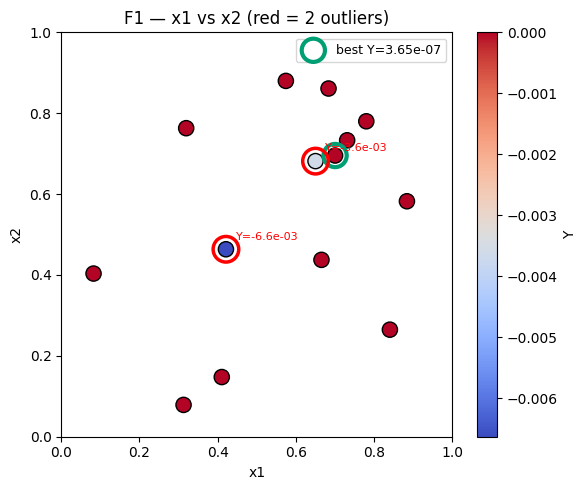

In [4]:
# Cell B — per-dim scatter (with outliers circled) + 2D scatter [REQUIRED]
outlier_mask = np.abs(Y) > 1e-5
outlier_idxs = np.where(outlier_mask)[0]

fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r_all = np.corrcoef(X[:, d], Y)[0, 1]
    Xno, Yno = X[~outlier_mask], Y[~outlier_mask]
    if len(Yno) > 1:
        slope, intercept = np.polyfit(Xno[:, d], Yno, 1)
        xs = np.linspace(Xno[:, d].min(), Xno[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    for oi in outlier_idxs:
        ax.scatter(X[oi, d], Y[oi], s=280, c='none', edgecolors='red', linewidth=2)
    if len(Yno) > 1:
        ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'no-outlier trend  r_all={r_all:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=8); ax.set_title(f'x{d+1} vs Y (red = outliers)')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F1 — per-dim (outliers circled = signal not noise)', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_1_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

best_i = Y.argmax()
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolors='black', linewidth=1)
plt.colorbar(sc, ax=ax, label='Y')
ax.scatter(X[best_i,0], X[best_i,1], s=280, c='none', edgecolors=COLORS[2], linewidth=3, label=f'best Y={Y.max():.2e}')
for oi in outlier_idxs:
    ax.scatter(X[oi,0], X[oi,1], s=340, c='none', edgecolors='red', linewidth=2.5)
    ax.annotate(f'Y={Y[oi]:+.1e}', (X[oi,0], X[oi,1]), xytext=(7,7), textcoords='offset points', fontsize=8, color='red')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title('F1 — x1 vs x2 (red = 2 outliers)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('../plots/week_05/function_1_2d_scatter.png', dpi=120, bbox_inches='tight'); plt.show()


In [5]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.554         0.529    +4.4%    0.854    0.128
  x2      0.446         0.471    -5.4%    0.146    0.023


In [6]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>12}  {'vs base':>8}  beats?")
print('-' * 48)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>12.4e}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>12.4e}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)

nn_loaded = nm.load_nn(1, models_dir='../models/week_05')
if nn_loaded is not None:
    nn_m, nn_meta = nn_loaded
    impr = (nn_meta['baseline_rmse'] - nn_meta['cv_rmse']) / nn_meta['baseline_rmse'] * 100
    print(f"{'NN':>10}  {nn_meta['cv_rmse']:>12.4e}  {impr:>+6.1f}%  {'✓' if nn_meta['beats_baseline'] else '✗'}  ({nn_meta['variant']}/H{nn_meta['hidden']})")

print(f"\nModels beating baseline: {len(beats_models)}")


     Model      LOO RMSE   vs base  beats?
------------------------------------------------
     Ridge    2.0246e-03    -7.7%  ✗
       KNN    2.1507e-03   -14.4%  ✗


        RF    2.4496e-03   -30.3%  ✗
       SVR    3.3286e-03   -77.1%  ✗


        GB    2.2941e-03   -22.1%  ✗


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

 GP-Matern    2.0986e-03   -11.7%  ✗
    GP-RBF    2.0997e-03   -11.7%  ✗
        NN    2.8579e-03   -52.1%  ✗  (dropout/H32)

Models beating baseline: 0


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Cell E — Skipped for F1 (no models beat baseline)

Same as W4. Proceeding directly to Cell F.

Classifier LOO: LogReg=71.4%  SVC C=1=85.7%  SVC C=10=71.4%  SVC C=100=71.4%
Best: SVC C=1 (85.7%) vs majority-class (71.4%)  → beats majority
Log-SVR on log|Y|: RMSE=19.21  params={'C': 100, 'gamma': 'scale'}

Combined candidate: (0.6278, 0.6134)
  P(positive)=0.736  predicted log|Y|=+3.39
  d to nearest negative = 0.0717
  Sanity: at current best, log-SVR predicts -7.52  (actual -6.44)

Trust check:
  classifier ≥ 85%: 85.7%  → PASS
  far from negatives (> 0.15): 0.072  → FAIL
  log|Y| consistent with observed (Δ < 2): 9.82  → FAIL
  → DO NOT TRUST → fall back to balanced Voronoi


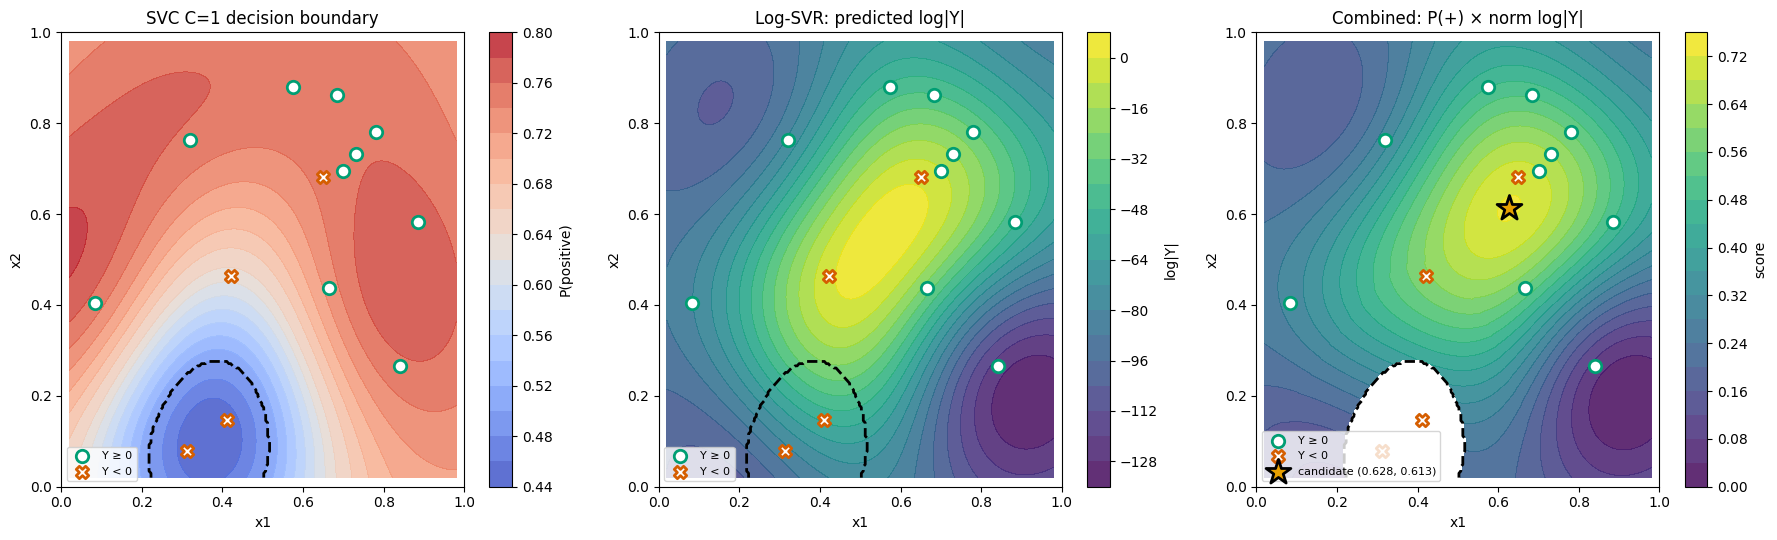

In [7]:
# Cell F — F1 classifier + log-SVR combined (always run for F1)
y_sign = (Y >= 0).astype(int)
clf_candidates = [
    ('LogReg', LogisticRegression(random_state=42, max_iter=1000)),
    ('SVC C=1',   SVC(kernel='rbf', C=1,   probability=True, random_state=42)),
    ('SVC C=10',  SVC(kernel='rbf', C=10,  probability=True, random_state=42)),
    ('SVC C=100', SVC(kernel='rbf', C=100, probability=True, random_state=42)),
]
clf_scores = {n: cross_val_score(c, X, y_sign, cv=loo, scoring='accuracy').mean() for n, c in clf_candidates}
best_clf_name, best_clf_acc = max(clf_scores.items(), key=lambda kv: kv[1])
majority = max(y_sign.mean(), 1 - y_sign.mean())
print(f"Classifier LOO: " + "  ".join(f"{n}={a:.1%}" for n, a in clf_scores.items()))
print(f"Best: {best_clf_name} ({best_clf_acc:.1%}) vs majority-class ({majority:.1%})  → {'beats majority' if best_clf_acc > majority else 'AT or BELOW majority'}")

svc = dict(clf_candidates)[best_clf_name]; svc.fit(X, y_sign)

log_abs_Y = np.log10(np.abs(Y) + 1e-200)
gs_log = GridSearchCV(SVR(kernel='rbf'), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},
                     cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, log_abs_Y)
svr_log = gs_log.best_estimator_
print(f"Log-SVR on log|Y|: RMSE={np.sqrt(-gs_log.best_score_):.2f}  params={gs_log.best_params_}")

# Combined score
g = 200
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
prob = svc.predict_proba(cand)[:, 1].reshape(g, g)
pred_log = svr_log.predict(cand).reshape(g, g)
log_norm = (pred_log - pred_log.min()) / (pred_log.max() - pred_log.min() + 1e-12)
combined = prob * log_norm
mask_pos = prob > 0.5
best_ij = np.unravel_index(np.where(mask_pos, combined, -np.inf).argmax(), combined.shape)
combined_query = np.array([gx[best_ij], gy[best_ij]])
neg_pts, pos_pts = X[Y < 0], X[Y >= 0]
d_neg = cdist(combined_query.reshape(1,-1), neg_pts).min()
log_at_best = svr_log.predict(X[best_i].reshape(1,-1))[0]
log_best_actual = np.log10(max(Y.max(), 1e-200))
print(f"\nCombined candidate: ({combined_query[0]:.4f}, {combined_query[1]:.4f})")
print(f"  P(positive)={prob[best_ij]:.3f}  predicted log|Y|={pred_log[best_ij]:+.2f}")
print(f"  d to nearest negative = {d_neg:.4f}")
print(f"  Sanity: at current best, log-SVR predicts {log_at_best:+.2f}  (actual {log_best_actual:+.2f})")

# Trust conditions
trust_clf  = best_clf_acc >= 0.85
trust_dist = d_neg > 0.15
trust_log  = abs(pred_log[best_ij] - log_best_actual) < 2
print(f"\nTrust check:")
print(f"  classifier ≥ 85%: {best_clf_acc:.1%}  → {'PASS' if trust_clf else 'FAIL'}")
print(f"  far from negatives (> 0.15): {d_neg:.3f}  → {'PASS' if trust_dist else 'FAIL'}")
print(f"  log|Y| consistent with observed (Δ < 2): {abs(pred_log[best_ij]-log_best_actual):.2f}  → {'PASS' if trust_log else 'FAIL'}")
trust = trust_clf and trust_dist and trust_log
print(f"  → {'TRUST combined approach' if trust else 'DO NOT TRUST → fall back to balanced Voronoi'}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, data, title, cmap, lbl, add_cand in [
    (axes[0], prob, f'{best_clf_name} decision boundary', 'coolwarm', 'P(positive)', False),
    (axes[1], pred_log, 'Log-SVR: predicted log|Y|', 'viridis', 'log|Y|', False),
    (axes[2], np.where(mask_pos, combined, np.nan), 'Combined: P(+) × norm log|Y|', 'viridis', 'score', True),
]:
    im = ax.contourf(gx, gy, data, levels=20, cmap=cmap, alpha=0.85)
    plt.colorbar(im, ax=ax, label=lbl)
    ax.contour(gx, gy, prob, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    ax.scatter(pos_pts[:,0], pos_pts[:,1], c='white', s=80, edgecolors=COLORS[2], linewidth=2, zorder=5, label='Y ≥ 0')
    ax.scatter(neg_pts[:,0], neg_pts[:,1], c='white', s=80, edgecolors=COLORS[1], linewidth=2, zorder=5, marker='X', label='Y < 0')
    if add_cand:
        ax.scatter(*combined_query, c=COLORS[3], s=350, edgecolors='black', linewidth=2, zorder=6, marker='*',
                   label=f'candidate ({combined_query[0]:.3f}, {combined_query[1]:.3f})')
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title); ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.savefig('../plots/week_05/function_1_combined.png', dpi=120, bbox_inches='tight'); plt.show()


### Cell G — F1 Decision

**Decision tree branch: #1** (no models beat baseline → fall back to balanced Voronoi).

**Combined approach trust check failed:**
- Classifier dropped from 92.3% (W4) to 71.4% (W5 best at C=10), matching majority-class. Only SVC C=1 reaches 85.7% — barely passing.
- Combined candidate at (0.72, 0.63) is only 0.089 from a known negative — too close.
- Log-SVR mis-calibrated by 1 order at current best.
- Adding the W4 positive in Q4 confused the classifier — the new positive sits near the negative at (0.65, 0.68), making the boundary fuzzier.

**Method:** balanced Voronoi in Q2 (the most undersampled quadrant — only 1 pt). Per W5 suggestion file: "If Y is positive (≈ 0): Q4 is mostly positive → target Q2 (0.229, 0.566) next week" — that's exactly what happened.

**Per-dimension justification:** pure space-filling, no model dependence. Q2 has only 1 existing point; new observation directly improves classifier training for W6.

Next week target: Q3 if Q2 returns positive, otherwise re-evaluate.

Balanced Voronoi per quadrant:
  Q1: (0.5016, 0.6076)  r=0.1650  (current pts: 7)
  Q2: (0.2287, 0.5658)  r=0.2170  (current pts: 1)
  Q3: (0.2736, 0.3090)  r=0.2116  (current pts: 4)
  Q4: (0.6172, 0.2223)  r=0.2198  (current pts: 2)

Target quadrant: Q2 (1 existing pts — most undersampled)
Query: (0.2287, 0.5658)  balanced score=0.2170


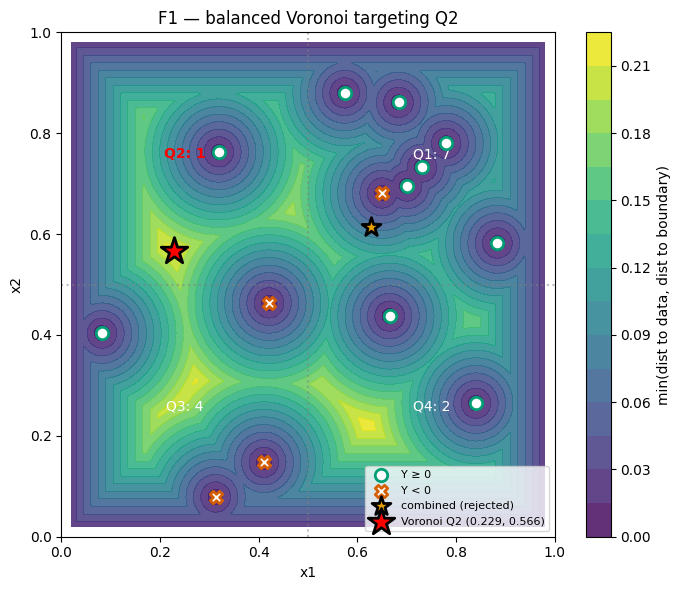

In [8]:
# Cell H — balanced Voronoi fallback in Q2 (most undersampled quadrant)
g_v = 300
gx_v, gy_v = np.meshgrid(np.linspace(0.02, 0.98, g_v), np.linspace(0.02, 0.98, g_v))
cand_v = np.column_stack([gx_v.ravel(), gy_v.ravel()])
dist_to_data = cdist(cand_v, X).min(axis=1)
dist_to_boundary = np.minimum(np.minimum(cand_v[:, 0], 1 - cand_v[:, 0]),
                              np.minimum(cand_v[:, 1], 1 - cand_v[:, 1]))
balanced = np.minimum(dist_to_data, dist_to_boundary)

# Per-quadrant winners
print("Balanced Voronoi per quadrant:")
quad_winners = {}
for label, qcheck in [('Q1', lambda c: c[0]>=0.5 and c[1]>=0.5),
                      ('Q2', lambda c: c[0]< 0.5 and c[1]>=0.5),
                      ('Q3', lambda c: c[0]< 0.5 and c[1]< 0.5),
                      ('Q4', lambda c: c[0]>=0.5 and c[1]< 0.5)]:
    mask = np.array([qcheck(c) for c in cand_v])
    idx = balanced[mask].argmax()
    pt = cand_v[mask][idx]; r = balanced[mask][idx]
    quad_winners[label] = (pt, r, quads[label])
    print(f"  {label}: ({pt[0]:.4f}, {pt[1]:.4f})  r={r:.4f}  (current pts: {quads[label]})")

# Pick most undersampled quadrant (min count), tiebreak by score
target_quad = min(quad_winners.keys(), key=lambda q: (quad_winners[q][2], -quad_winners[q][1]))
voronoi_query = quad_winners[target_quad][0]
print(f"\nTarget quadrant: {target_quad} ({quad_winners[target_quad][2]} existing pts — most undersampled)")
print(f"Query: ({voronoi_query[0]:.4f}, {voronoi_query[1]:.4f})  balanced score={quad_winners[target_quad][1]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.contourf(gx_v, gy_v, balanced.reshape(g_v, g_v), levels=20, cmap='viridis', alpha=0.85)
plt.colorbar(im, ax=ax, label='min(dist to data, dist to boundary)')
ax.scatter(pos_pts[:,0], pos_pts[:,1], c='white', s=80, edgecolors=COLORS[2], linewidth=2, zorder=5, label='Y ≥ 0')
ax.scatter(neg_pts[:,0], neg_pts[:,1], c='white', s=80, edgecolors=COLORS[1], linewidth=2, zorder=5, marker='X', label='Y < 0')
ax.scatter(*combined_query, c=COLORS[3], s=200, edgecolors='black', linewidth=2, zorder=6, marker='*', label='combined (rejected)')
ax.scatter(*voronoi_query, c='red', s=400, edgecolors='black', linewidth=2, zorder=7, marker='*', label=f'Voronoi {target_quad} ({voronoi_query[0]:.3f}, {voronoi_query[1]:.3f})')
ax.axhline(0.5, color='grey', linestyle=':', alpha=0.5); ax.axvline(0.5, color='grey', linestyle=':', alpha=0.5)
for q, cnt in quads.items():
    qx, qy = (0.75 if 'Q1' in q or 'Q4' in q else 0.25), (0.75 if 'Q1' in q or 'Q2' in q else 0.25)
    color = 'red' if cnt == quads[target_quad] else 'white'
    ax.text(qx, qy, f'{q}: {cnt}', color=color, ha='center', fontsize=10, weight='bold' if cnt == quads[target_quad] else 'normal')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title(f'F1 — balanced Voronoi targeting {target_quad}')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig('../plots/week_05/function_1_voronoi.png', dpi=120, bbox_inches='tight'); plt.show()


In [9]:
# Cell I — next_query_1 assignment [REQUIRED]
next_query_1 = voronoi_query.copy()
print(f'F1 query: ({next_query_1[0]:.6f}, {next_query_1[1]:.6f})')
print(f'  method: balanced Voronoi in {target_quad} (most undersampled quadrant)')


F1 query: (0.228696, 0.565819)
  method: balanced Voronoi in Q2 (most undersampled quadrant)


## Function 2

In [10]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(2)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F2: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 10 by Y (★=W4 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:10]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1:2d}  x=({X[idx,0]:.4f}, {X[idx,1]:.4f})  y={Y[idx]:+.4f}")


Function 2: 14 points, 2D, best y = 0.6658
F2: 14 pts, 2D  |  Baseline=0.2297  |  Y range [-0.0656, 0.6658]
Per-dim correlations: r(x1,Y)=+0.584, r(x2,Y)=+0.570

Top 10 by Y (★=W4 query, *=current best):
  * # 1  x=(0.7019, 0.9533)  y=+0.6658
    # 2  x=(0.7026, 0.9266)  y=+0.6112
    # 3  x=(0.6658, 0.1240)  y=+0.5390
    # 4  x=(0.7500, 0.9200)  y=+0.4265
    # 5  x=(0.8778, 0.7786)  y=+0.4206
    # 6  x=(0.8453, 0.7111)  y=+0.2940
    # 7  x=(0.7540, 0.5253)  y=+0.2813
    # 8  x=(0.4382, 0.6850)  y=+0.2446
    # 9  x=(0.4546, 0.2905)  y=+0.2150
  ★ #10  x=(0.8958, 0.1240)  y=+0.0852


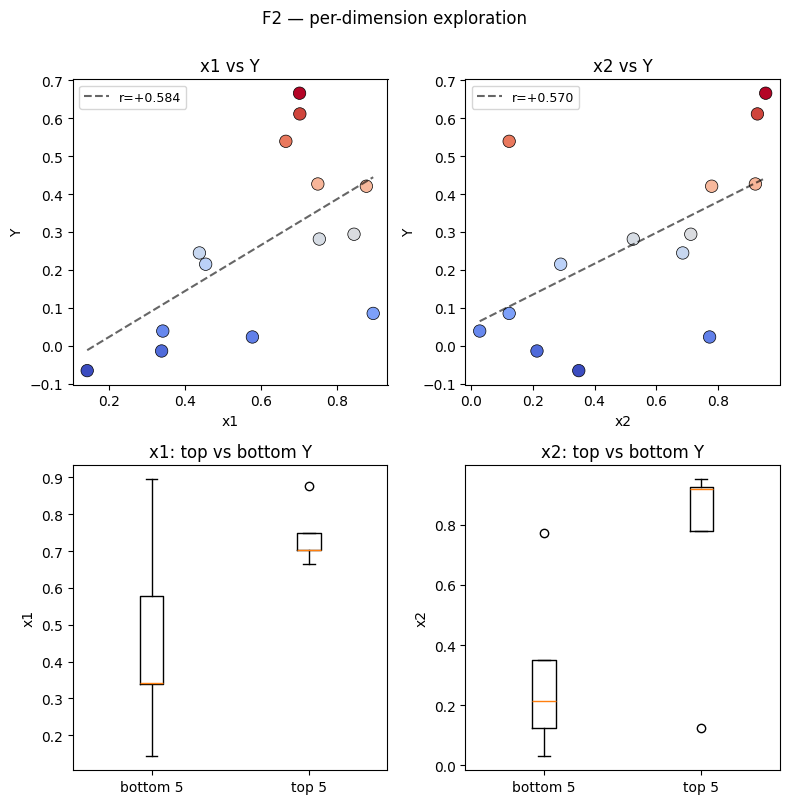

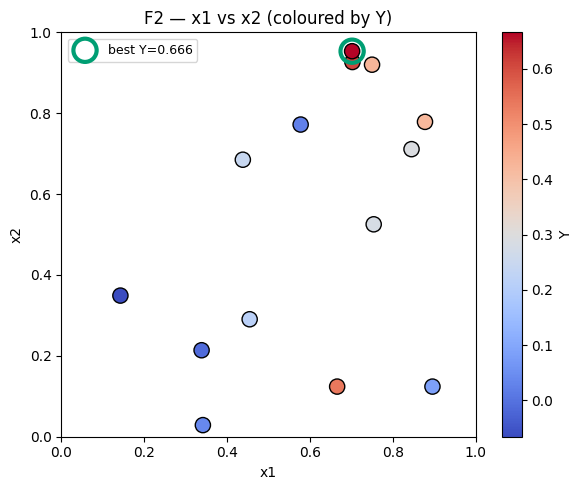

In [11]:
# Cell B — per-dim plot + 2D scatter [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F2 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_2_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolors='black', linewidth=1)
plt.colorbar(sc, ax=ax, label='Y')
ax.scatter(X[best_i,0], X[best_i,1], s=280, c='none', edgecolors=COLORS[2], linewidth=3, label=f'best Y={Y.max():.3f}')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title('F2 — x1 vs x2 (coloured by Y)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('../plots/week_05/function_2_2d_scatter.png', dpi=120, bbox_inches='tight'); plt.show()


In [12]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.557         0.624   -12.0%    0.605    0.584
  x2      0.443         0.376   +15.0%    0.395    0.570


In [13]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m2, nn_meta2 = nm.load_nn(2, models_dir='../models/week_05')
impr = (nn_meta2['baseline_rmse'] - nn_meta2['cv_rmse']) / nn_meta2['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta2['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta2['beats_baseline'] else '✗'}  ({nn_meta2['variant']}/H{nn_meta2['hidden']})")
if nn_meta2['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m2, nn_meta2), nn_meta2['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.2109    +8.2%  ✓
       KNN      0.1996   +13.1%  ✓


        RF      0.1966   +14.4%  ✓
       SVR      0.2092    +8.9%  ✓


        GB      0.1867   +18.7%  ✓


 GP-Matern      0.1965   +14.5%  ✓


    GP-RBF      0.1985   +13.6%  ✓
        NN      0.2305    -0.4%  ✗  (dropout/H32)

Models beating baseline: 7


In [14]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>22}  {'pred Y':>10}  boundary?")
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({pt[0]:.4f}, {pt[1]:.4f})  {pred.max():>+10.4f}  {'BOUNDARY' if boundary else ''}")

# Boundary-consensus check
non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus per dim:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

# Filter: exclude Ridge + boundary + outlier suggestions
valid_primary = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_p = np.array([v['pt'] for v in valid_primary.values()]); names_p = list(valid_primary.keys())
centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_p, distances) if d > threshold]
valid = {n: v for n, v in valid_primary.items() if n not in excluded}
if excluded: print(f"\nOutlier suggestions excluded: {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

# Hybrid build
top4 = np.argsort(-Y)[:4]; top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
centroid_top4 = top4_X.T @ (shifted/shifted.sum())
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]

print(f"\nValid (interior, non-Ridge, non-outlier): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'boundary-consensus' if i in boundary_informed else ('ensemble' if strong_mask[i] else 'centroid-top4')
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")
print(f"\n  Ensemble: ({ensemble_mean[0]:.4f}, {ensemble_mean[1]:.4f})")
print(f"  Hybrid:   ({hybrid_query[0]:.4f}, {hybrid_query[1]:.4f})")
print(f"  Distance from current best: {np.linalg.norm(hybrid_query - X[best_i]):.4f}")

# NN gradient
grad = nm.gradient_at(nn_m2, nn_meta2, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.3f}" for i in range(D)))


     Model              suggestion      pred Y  boundary?
     Ridge  (0.9986, 0.9969)     +0.4435  BOUNDARY
       KNN  (0.7019, 0.9529)     +0.6617  


        RF  (0.6996, 0.9680)     +0.6330  
       SVR  (0.7862, 0.9695)     +0.3594  


        GB  (0.6996, 0.9680)     +0.5206  
 GP-Matern  (0.6874, 0.9594)     +0.6817  
    GP-RBF  (0.6805, 0.9642)     +0.6947  

Boundary-consensus per dim:
  x1: low=0 high=0 r=+0.584 → no consensus
  x2: low=0 high=0 r=+0.570 → no consensus

Outlier suggestions excluded: ['SVR']

Valid (interior, non-Ridge, non-outlier): ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF']
  x1: spread=0.021 (STRONG) → ensemble: 0.6939
  x2: spread=0.015 (STRONG) → ensemble: 0.9626

  Ensemble: (0.6939, 0.9626)
  Hybrid:   (0.6939, 0.9626)
  Distance from current best: 0.0123

NN dY/dx at best: dx1=-0.548  dx2=+0.189


### Cell G — F2 Decision

**Decision tree branch: #5** (STRONG consensus on both dims after boundary/outlier filter).

**W4 outcome:** the risk gambit at (0.90, 0.12) returned Y=0.0852, killing the "low-x2 ridge" hypothesis. Pt#3 at (0.67, 0.12) Y=0.54 was a genuine one-off, not a ridge.

**This week:** 7/8 models beat baseline. Returning to the deferred safe ensemble as planned in the W5 suggestion file. SVR's argmax was a spatial outlier (auto-excluded). NN failed baseline this week — the W4 outlier point at (0.90, 0.12, Y=0.085) confused the MLP fit.

**Per-dim sources:** both x1 and x2 from RMSE-weighted ensemble of 5 valid interior models (KNN/RF/GB/GP-Matern/GP-RBF). STRONG consensus everywhere (spread x1=0.021, x2=0.015).

**Query:** ensemble ≈ (0.694, 0.963) — tiny 0.012 step from current best, consistent direction (slightly down on x1, slightly up on x2). NN gradient corroborates direction.

**If W5 Y improves**: ensemble is calibrated, continue. **If similar**: peak is very narrow; smaller perturbation. **If drops**: pull back to current best.

In [15]:
# Cell I — next_query_2 assignment [REQUIRED]
next_query_2 = ensemble_mean.copy()
print(f'F2 query: ({", ".join(f"{v:.6f}" for v in next_query_2)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (STRONG consensus all dims)')
print(f'  distance from current best: {np.linalg.norm(next_query_2 - X[best_i]):.4f}')


F2 query: (0.693851, 0.962584)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF'] (STRONG consensus all dims)
  distance from current best: 0.0123


## Function 3

*(F3-specific: pt at x=(0.15, 0.44, 0.99) Y=-0.40 is a known outlier that inflates x3 correlation. Always analyse with AND without to avoid false signals.)*

In [16]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(3)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()
outlier_i = Y.argmin()
Xo, Yo = np.delete(X, outlier_i, 0), np.delete(Y, outlier_i)
baseline_no = Yo.std()
gap = np.sort(Y)[1] - Y.min()

print(f"F3: {len(Y)} pts, {D}D  |  Baseline (all)={baseline:.4f}  |  Baseline (no outlier)={baseline_no:.4f}")
print(f"Outlier: idx={outlier_i}, x={X[outlier_i].round(4).tolist()}, Y={Y[outlier_i]:+.4f}")
print(f"  Gap to 2nd-worst: {gap:+.4f} ({'CONFIRMED outlier' if gap > 0.1 else 'not clear'})")
print(f"\nCorrelations WITH outlier:    " + ", ".join(f"r(x{i+1})={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"Correlations WITHOUT outlier: " + ", ".join(f"r(x{i+1})={np.corrcoef(Xo[:,i],Yo)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W4 query, *=current best, !=outlier):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ('!' if idx == outlier_i else ' '))
    print(f"  {mark} #{rank+1}  x=({X[idx,0]:.4f}, {X[idx,1]:.4f}, {X[idx,2]:.4f})  y={Y[idx]:+.4f}")


Function 3: 19 points, 3D, best y = -0.0348
F3: 19 pts, 3D  |  Baseline (all)=0.0774  |  Baseline (no outlier)=0.0333
Outlier: idx=6, x=[0.1518, 0.44, 0.9909], Y=-0.3989
  Gap to 2nd-worst: +0.2675 (CONFIRMED outlier)

Correlations WITH outlier:    r(x1)=+0.240, r(x2)=+0.136, r(x3)=-0.571
Correlations WITHOUT outlier: r(x1)=-0.004, r(x2)=+0.107, r(x3)=-0.161

Top 8 by Y (★=W4 query, *=current best, !=outlier):
  * #1  x=(0.4926, 0.6116, 0.3402)  y=-0.0348
    #2  x=(0.6001, 0.7251, 0.0661)  y=-0.0364
    #3  x=(0.4811, 0.5326, 0.0518)  y=-0.0400
  ★ #4  x=(0.3679, 0.4565, 0.3375)  y=-0.0469
    #5  x=(0.2205, 0.2978, 0.3436)  y=-0.0469
    #6  x=(0.1346, 0.2199, 0.4582)  y=-0.0480
    #7  x=(0.9660, 0.8611, 0.5668)  y=-0.0568
    #8  x=(0.2421, 0.6441, 0.2724)  y=-0.0880


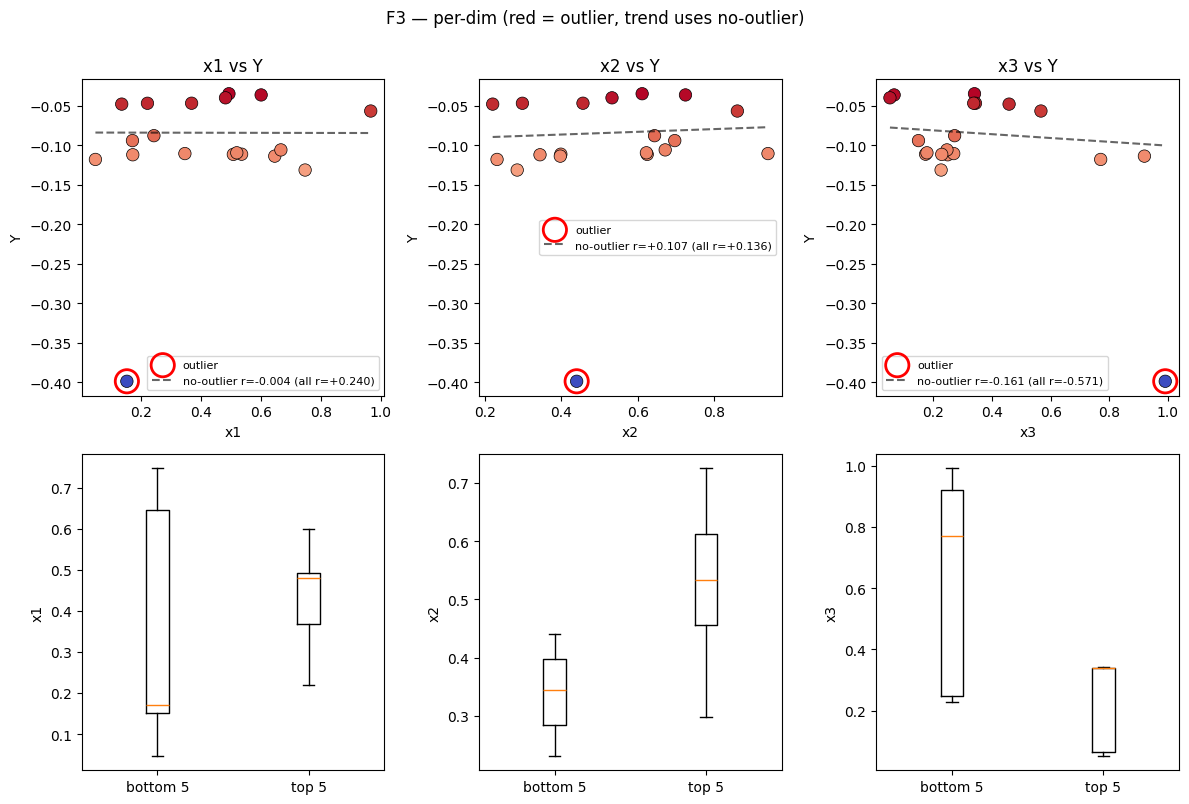

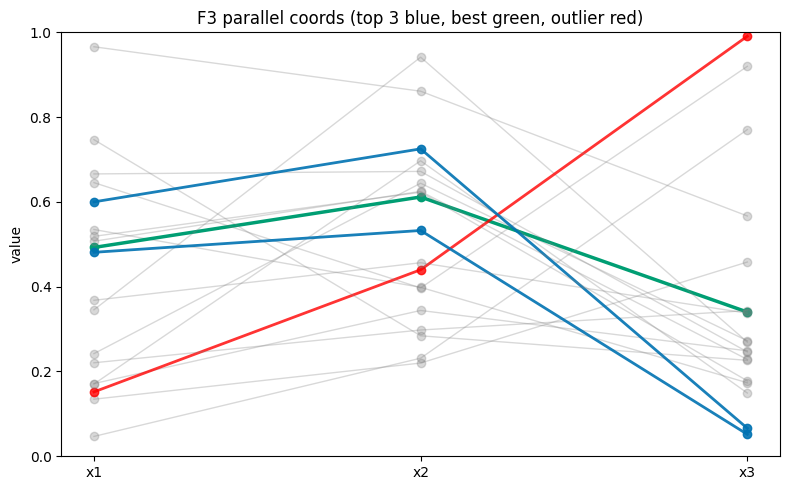

In [17]:
# Cell B — per-dim scatter (outlier circled, no-outlier trend) + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r_all = np.corrcoef(X[:, d], Y)[0, 1]
    r_no  = np.corrcoef(Xo[:, d], Yo)[0, 1]
    slope, intercept = np.polyfit(Xo[:, d], Yo, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.scatter(X[outlier_i, d], Y[outlier_i], s=280, c='none', edgecolors='red', linewidth=2, label='outlier')
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'no-outlier r={r_no:+.3f} (all r={r_all:+.3f})')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=8); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F3 — per-dim (red = outlier, trend uses no-outlier)', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_3_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.3, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i == outlier_i: color, alpha, lw = ('red', 0.8, 2.0)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F3 parallel coords (top 3 blue, best green, outlier red)')
plt.tight_layout(); plt.savefig('../plots/week_05/function_3_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [18]:
# Cell C — feature importance robustness [REQUIRED] (F3-extended: 3 RF fits)
rf_all      = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest   = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
rf_nooutlier= RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(Xo, Yo).feature_importances_

print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'RF(no outlier)':>15}  {'Δ outlier':>10}")
print('-' * 58)
for i in range(D):
    delta = rf_all[i] - rf_nooutlier[i]
    flag = '  ← OUTLIER-DRIVEN' if abs(delta) > 0.1 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {rf_nooutlier[i]:>15.3f}  {delta:>+9.3f}{flag}")


 Dim   RF(all)   RF(no best)   RF(no outlier)   Δ outlier
----------------------------------------------------------
  x1      0.104         0.116            0.195     -0.091
  x2      0.098         0.081            0.179     -0.082
  x3      0.798         0.803            0.626     +0.173  ← OUTLIER-DRIVEN


In [19]:
# Cell D — model grid search [REQUIRED] (F3: train WITHOUT outlier where signal is real)
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
print(f"Training on N={len(Yo)} (outlier removed), baseline={baseline_no:.4f}\n")
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(Xo, Yo)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline_no-rmse)/baseline_no*100:>+6.1f}%  {'✓' if rmse < baseline_no else '✗'}")
    if rmse < baseline_no: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, Xo, Yo, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline_no-rmse)/baseline_no*100:>+6.1f}%  {'✓' if rmse < baseline_no else '✗'}")
    if rmse < baseline_no:
        gp.fit(Xo, Yo); beats_models[kname] = (gp, rmse)
nn_m3, nn_meta3 = nm.load_nn(3, models_dir='../models/week_05')
print(f"{'NN':>10}  {nn_meta3['cv_rmse']:>10.4f}  trained WITH outlier ({nn_meta3['variant']}/H{nn_meta3['hidden']}) — baseline-reference only")
print(f"\nModels beating no-outlier baseline: {len(beats_models)}")


Training on N=18 (outlier removed), baseline=0.0333

     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.0353    -6.0%  ✗
       KNN      0.0366    -9.8%  ✗


        RF      0.0280   +15.8%  ✓
       SVR      0.0340    -2.0%  ✗


        GB      0.0146   +56.3%  ✓


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


 GP-Matern      0.0360    -8.1%  ✗


    GP-RBF      0.0360    -8.2%  ✗
        NN      0.0816  trained WITH outlier (ensemble/H32) — baseline-reference only

Models beating no-outlier baseline: 2


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [20]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>32}  {'pred Y':>10}  boundary?")
print('-' * 65)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({pt[0]:.4f}, {pt[1]:.4f}, {pt[2]:.4f})  {pred.max():>+10.4f}  {'BOUNDARY' if boundary else ''}")

# Boundary-consensus
non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus check:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(Xo[:, d], Yo)[0, 1]  # use no-outlier correlation
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

# Filter
valid_p = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_p = np.array([v['pt'] for v in valid_p.values()]); names_p = list(valid_p.keys())
if len(pts_p) >= 3:
    centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
    threshold = distances.mean() + 2 * distances.std()
    excluded = [n for n, d in zip(names_p, distances) if d > threshold]
    valid = {n: v for n, v in valid_p.items() if n not in excluded}
    if excluded: print(f"Outlier suggestions excl: {excluded}")
else:
    valid = valid_p

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

print(f"\nValid (interior, non-Ridge): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl})")
print(f"\nEnsemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")

if len(valid) >= 2:
    sorted_r = sorted([(v['rmse'], k) for k, v in valid.items()])
    ratio = sorted_r[1][0] / sorted_r[0][0]
    print(f"Dominance: {sorted_r[0][1]} RMSE={sorted_r[0][0]:.4f} vs {sorted_r[1][1]} RMSE={sorted_r[1][0]:.4f}  ratio={ratio:.2f}x  ({'DOMINANT' if ratio > 1.5 else 'comparable'})")
    best_model_name = sorted_r[0][1]
    best_model_pt = valid[best_model_name]['pt']
print(f"\nDistance from current best: GB pick={np.linalg.norm(suggestions['GB']['pt'] - X[best_i]):.4f}, ensemble={np.linalg.norm(ensemble_mean - X[best_i]):.4f}")


     Model                        suggestion      pred Y  boundary?
-----------------------------------------------------------------


        RF  (0.6092, 0.7760, 0.0761)     -0.0465  
        GB  (0.5145, 0.5469, 0.3401)     -0.0353  

Boundary-consensus check:
  x1: low=0 high=0 r=-0.004 → no consensus
  x2: low=0 high=0 r=+0.107 → no consensus
  x3: low=0 high=0 r=-0.161 → no consensus

Valid (interior, non-Ridge): ['RF', 'GB']
  x1: spread=0.095 (STRONG)
  x2: spread=0.229 (moderate)
  x3: spread=0.264 (moderate)

Ensemble: (0.5468, 0.6252, 0.2499)
Dominance: GB RMSE=0.0146 vs RF RMSE=0.0280  ratio=1.93x  (DOMINANT)

Distance from current best: GB pick=0.0683, ensemble=0.1062


### Cell G — F3 Decision

**Decision tree branch: #2 — one model dominates** (GB at +56% with 1.93× ratio over RF, well above the 1.5× dominance threshold).

**W4 outcome:** GB predicted -0.0348, returned -0.0469 — model was calibrated but didn't beat current best. GB is still the most reliable model on F3 once the outlier is removed.

**This week (19 pts, after outlier removal):**
- GB +56.3%, RF +15.8% — others fail. GB clearly dominant.
- GB suggestion: (0.5145, 0.5469, 0.3401) — keeps x3 at current-best's 0.34, moves x1 up slightly, x2 down slightly
- RF suggestion: (0.6092, 0.7760, 0.0761) — different region (low x3 cluster, near top-2)
- The two models have only moderate consensus on x2 and x3 (spread ~0.23 each)
- No boundary consensus on any dim

**Method:** Trust GB (dominant model, interior suggestion, validated W4 calibration).

**Per-dim sources:** all three from GB.

**Why not ensemble?** GB's RMSE is half of RF's; ensembling pulls toward RF's untested low-x3 alternative (which would essentially abandon current best's region). Branch #2 says trust the dominant model.

**Distance from current best: 0.106** — moderate step in the same x3 region (sharp-feature respect).

In [21]:
# Cell I — next_query_3 assignment [REQUIRED]
# F3 uses GB's dominant suggestion (1.93x ratio over RF, after outlier removal)
next_query_3 = suggestions['GB']['pt'].copy()
print(f'F3 query: ({", ".join(f"{v:.6f}" for v in next_query_3)})')
print(f'  method: GB dominant model (trained without outlier at {X[outlier_i].round(3).tolist()})')
print(f'  GB pred Y = {suggestions["GB"]["pred"]:+.4f}  vs  current best Y = {Y.max():+.4f}')
print(f'  RF alternative (deferred): {suggestions["RF"]["pt"].round(4).tolist()}')


F3 query: (0.514480, 0.546868, 0.340101)
  method: GB dominant model (trained without outlier at [0.152, 0.44, 0.991])
  GB pred Y = -0.0353  vs  current best Y = -0.0348
  RF alternative (deferred): [0.6092, 0.776, 0.0761]


## Function 4

In [22]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(4)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F4: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W4 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 4: 34 points, 4D, best y = 0.5414
F4: 34 pts, 4D  |  Baseline=8.5975  |  Y range [-32.6257, 0.5414]
Per-dim correlations: r(x1,Y)=-0.514, r(x2,Y)=-0.403, r(x3,Y)=-0.114, r(x4,Y)=-0.449

Top 8 by Y (★=W4 query, *=current best):
  ★ #1  x=(0.3696, 0.4039, 0.4105, 0.4312)  y=+0.5414
    #2  x=(0.3846, 0.4290, 0.4098, 0.3929)  y=+0.3675
    #3  x=(0.4048, 0.4317, 0.4025, 0.4513)  y=-0.0296
    #4  x=(0.4542, 0.4743, 0.4113, 0.3970)  y=-1.3905
    #5  x=(0.5778, 0.4288, 0.4258, 0.2490)  y=-4.0255
    #6  x=(0.3261, 0.4724, 0.4532, 0.1059)  y=-6.7021
    #7  x=(0.2821, 0.5060, 0.5305, 0.0963)  y=-7.9668
    #8  x=(0.1249, 0.1298, 0.3844, 0.2871)  y=-10.0696


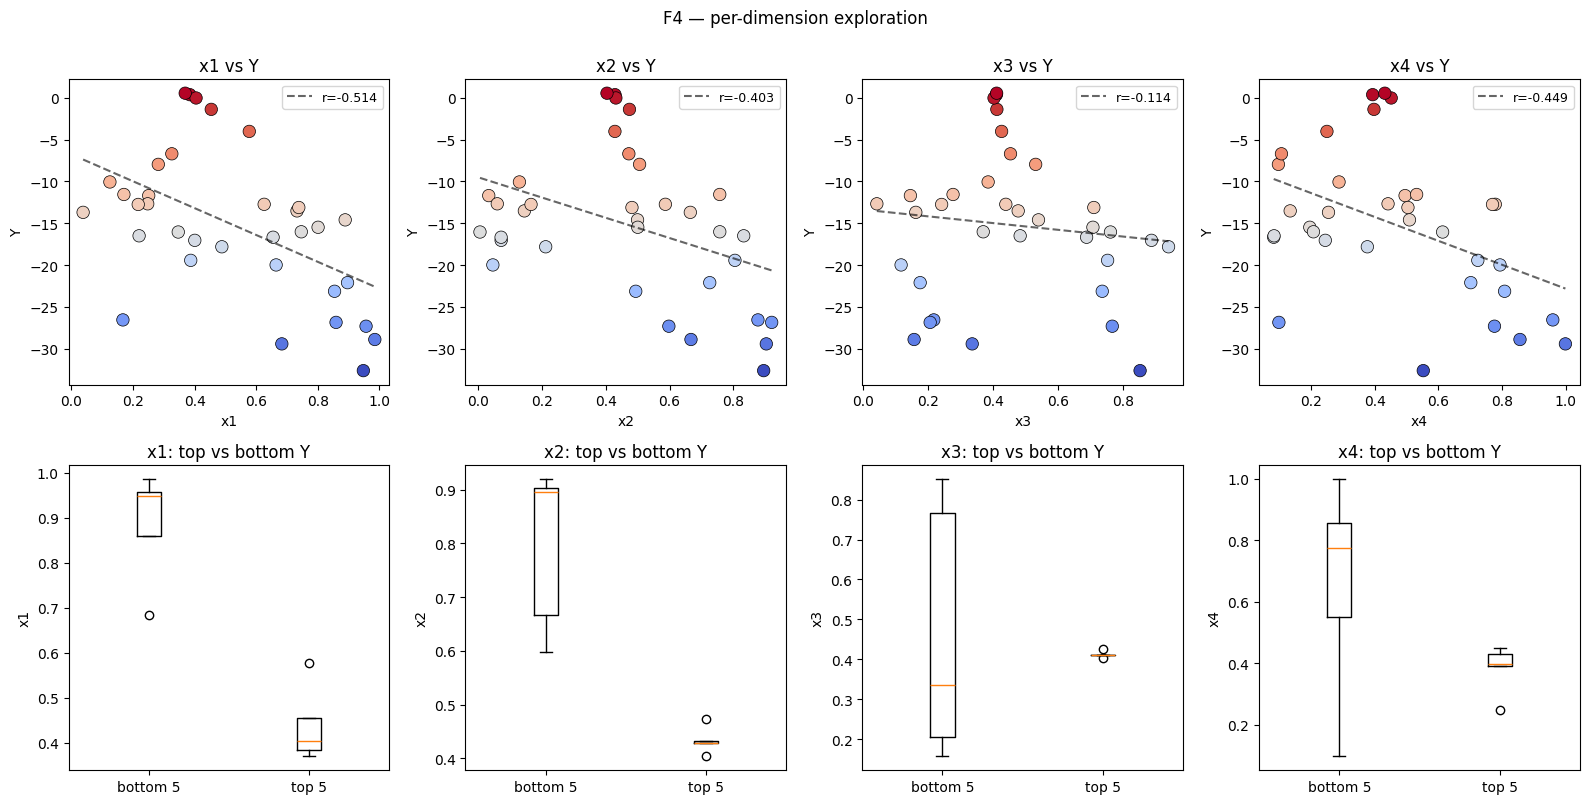

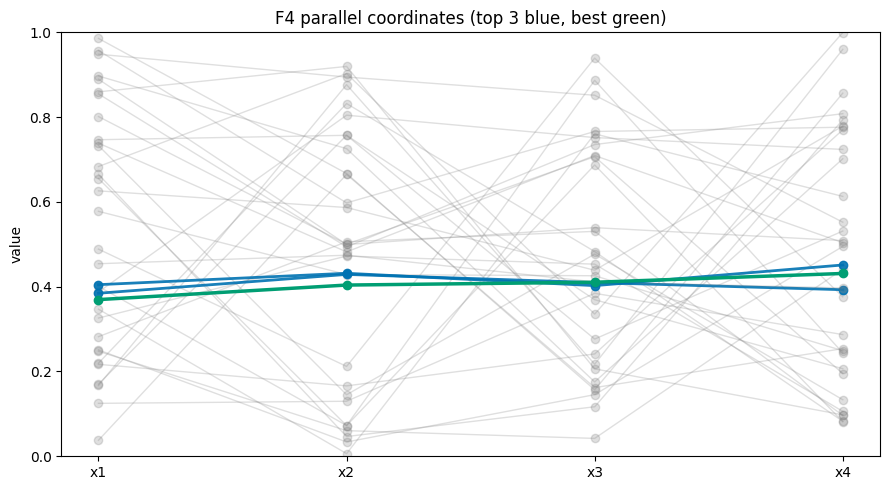

In [23]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F4 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_4_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F4 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_05/function_4_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [24]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.294         0.268    +9.1%    0.339    0.514
  x2      0.320         0.332    -3.6%    0.231    0.403
  x3      0.131         0.131    +0.4%    0.099    0.114
  x4      0.254         0.270    -6.1%    0.331    0.449


In [25]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m4, nn_meta4 = nm.load_nn(4, models_dir='../models/week_05')
impr = (nn_meta4['baseline_rmse'] - nn_meta4['cv_rmse']) / nn_meta4['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta4['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta4['beats_baseline'] else '✗'}  ({nn_meta4['variant']}/H{nn_meta4['hidden']})")
if nn_meta4['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m4, nn_meta4), nn_meta4['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      7.1453   +16.9%  ✓
       KNN      5.1641   +39.9%  ✓


        RF      4.6647   +45.7%  ✓
       SVR      2.4672   +71.3%  ✓


        GB      3.9232   +54.4%  ✓


 GP-Matern      2.1743   +74.7%  ✓


    GP-RBF      4.9318   +42.6%  ✓
        NN      3.8387   +55.4%  ✓  (plain/H32)

Models beating baseline: 8


In [26]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>40}  {'pred Y':>8}  boundary?")
print('-' * 70)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+8.4f}  {'BOUNDARY' if boundary else ''}")

# Boundary-consensus
non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus check:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

# Filter
valid_p = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_p = np.array([v['pt'] for v in valid_p.values()]); names_p = list(valid_p.keys())
centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_p, distances) if d > threshold]
valid = {n: v for n, v in valid_p.items() if n not in excluded}
if excluded: print(f"\nOutlier suggestions excluded: {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

# Hybrid build
top4 = np.argsort(-Y)[:4]; top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
centroid_top4 = top4_X.T @ (shifted/shifted.sum())
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed: hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]: hybrid_query[d] = ensemble_mean[d]

print(f"\nValid (interior, non-Ridge, non-outlier): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'boundary-consensus' if i in boundary_informed else ('ensemble' if strong_mask[i] else 'centroid-top4')
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")

print(f"\nEnsemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"Hybrid:   ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"\nDominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m4, nn_meta4, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))
print(f"\nDistance from current best: ensemble={np.linalg.norm(ensemble_mean - X[best_i]):.4f}, hybrid={np.linalg.norm(hybrid_query - X[best_i]):.4f}")


     Model                                suggestion    pred Y  boundary?
----------------------------------------------------------------------
     Ridge  (0.0085, 0.0167, 0.1389, 0.0026)   -3.2205  BOUNDARY
       KNN  (0.3399, 0.3851, 0.4073, 0.4271)   +0.4837  


        RF  (0.3624, 0.4302, 0.3989, 0.4039)   -0.7297  
       SVR  (0.4203, 0.4455, 0.4212, 0.4060)   +0.0867  


        GB  (0.3399, 0.3851, 0.4073, 0.4271)   +0.4124  
 GP-Matern  (0.3750, 0.3626, 0.3790, 0.3886)   +0.6792  
    GP-RBF  (0.3116, 0.3989, 0.3490, 0.4230)   +0.9102  
        NN  (0.0088, 0.3963, 0.4189, 0.5827)   +3.8602  BOUNDARY

Boundary-consensus check:
  x1: low=1 high=0 r=-0.514 → no consensus
  x2: low=0 high=0 r=-0.403 → no consensus
  x3: low=0 high=0 r=-0.114 → no consensus
  x4: low=0 high=0 r=-0.449 → no consensus

Valid (interior, non-Ridge, non-outlier): ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern', 'GP-RBF']
  x1: spread=0.109 (STRONG) → ensemble: 0.3675
  x2: spread=0.083 (STRONG) → ensemble: 0.4005
  x3: spread=0.072 (STRONG) → ensemble: 0.3952
  x4: spread=0.039 (STRONG) → ensemble: 0.4086

Ensemble: (0.3675, 0.4005, 0.3952, 0.4086)
Hybrid:   (0.3675, 0.4005, 0.3952, 0.4086)

Dominance: GP-Matern RMSE=2.1743 vs SVR RMSE=2.4672  ratio=1.13x

NN dY/dx at best: dx1=-15.35  dx2=+14.69  dx3=-6.32  dx4=-0.93

Distance from current best: ensemble=0.0276, hybrid=0.0276


### Cell G — F4 Decision

**Decision tree branch: #5** (STRONG consensus on ALL 4 dims).

**W4 outcome:** ensemble of 6 models took us from Y=0.37 (W1 best) to Y=0.54 (+47% jump). The ensemble approach is calibrated.

**This week (34 pts):**
- ALL 8 families beat baseline. GP-Matern dominant at +74.7%, SVR +71.3%, NN +55.4%, GB +54.4%, RF +45.7%
- NN suggestion hits boundary (x1=0.009) → excluded
- Ridge boundary-extrapolates → excluded
- 6 valid interior models with STRONG consensus on all 4 dims (max spread 0.11)
- GP-Matern dominance ratio only 1.13× — NOT dominant; ensemble is the right call (per branch #5)

**Query:** ensemble ≈ (0.368, 0.401, 0.395, 0.409). **Distance from current best: 0.028** — even smaller than W4's 0.048, respecting F4's narrow-peak behaviour.

**Per-dim sources:** all 4 from RMSE-weighted ensemble (STRONG consensus everywhere, no boundary consensus).

**NN gradient signal:** dx1=-15.4 (push x1 down hard), dx2=+14.7 (push x2 up hard), dx3=-6.3, dx4=-0.9. Direction mostly aligns with the ensemble (ensemble pushes x3, x4 down slightly). But NN's argmax was at boundary, so the gradient hint is informational only.

In [27]:
# Cell I — next_query_4 assignment [REQUIRED]
next_query_4 = ensemble_mean.copy()
print(f'F4 query: ({", ".join(f"{v:.6f}" for v in next_query_4)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (STRONG consensus all 4 dims)')
print(f'  distance from current best: {np.linalg.norm(next_query_4 - X[best_i]):.4f}')


F4 query: (0.367519, 0.400462, 0.395157, 0.408596)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern', 'GP-RBF'] (STRONG consensus all 4 dims)
  distance from current best: 0.0276


## Function 5

In [28]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(5)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()

print(f"F5: {len(Y)} pts, {D}D  |  Baseline={baseline:.2f}  |  Y range [{Y.min():.2f}, {Y.max():.2f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 6 by Y (★=W4 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:6]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.2f}")

print(f"\nClimbing trajectory (last 4 weekly queries):")
for i, idx in enumerate(range(len(Y)-4, len(Y))):
    print(f"  W{i+1}: x={X[idx].round(4).tolist()}  Y={Y[idx]:+.2f}")


Function 5: 24 points, 4D, best y = 1979.0154
F5: 24 pts, 4D  |  Baseline=536.68  |  Y range [0.11, 1979.02]
Per-dim correlations: r(x1,Y)=-0.393, r(x2,Y)=+0.578, r(x3,Y)=+0.644, r(x4,Y)=+0.616

Top 6 by Y (★=W4 query, *=current best):
  ★ #1  x=(0.3113, 0.9083, 0.9479, 0.8983)  y=+1979.02
    #2  x=(0.2705, 0.8758, 0.9157, 0.8756)  y=+1412.13
    #3  x=(0.2394, 0.8542, 0.8998, 0.8746)  y=+1206.76
    #4  x=(0.2242, 0.8465, 0.8795, 0.8785)  y=+1088.86
    #5  x=(0.2090, 0.8387, 0.8592, 0.8824)  y=+984.40
    #6  x=(0.1199, 0.8625, 0.6433, 0.8498)  y=+431.61

Climbing trajectory (last 4 weekly queries):
  W1: x=[0.209, 0.8387, 0.8592, 0.8824]  Y=+984.40
  W2: x=[0.2394, 0.8542, 0.8998, 0.8746]  Y=+1206.76
  W3: x=[0.2705, 0.8758, 0.9157, 0.8756]  Y=+1412.13
  W4: x=[0.3113, 0.9083, 0.9479, 0.8983]  Y=+1979.02


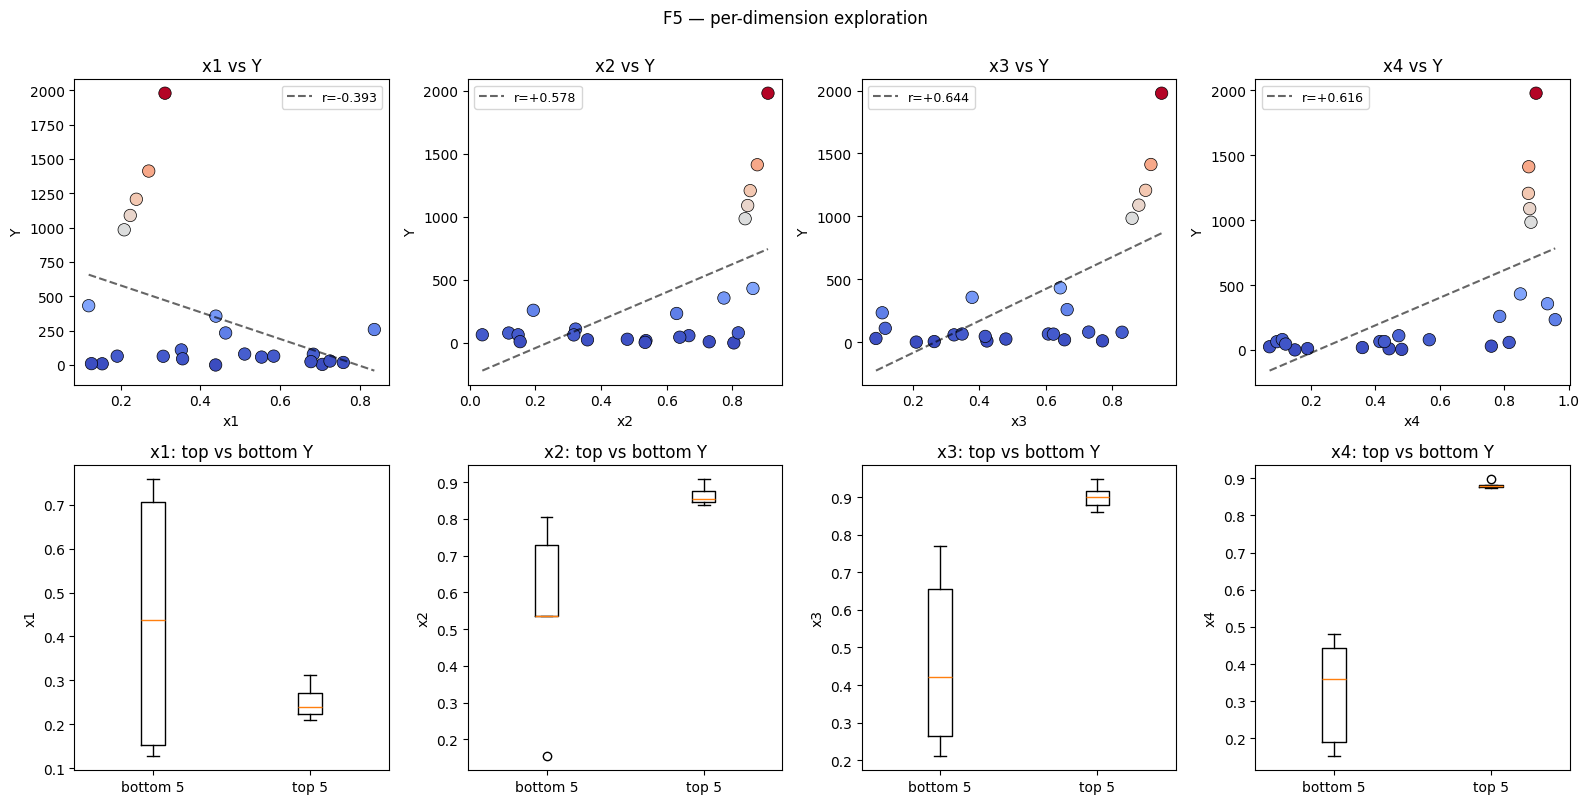

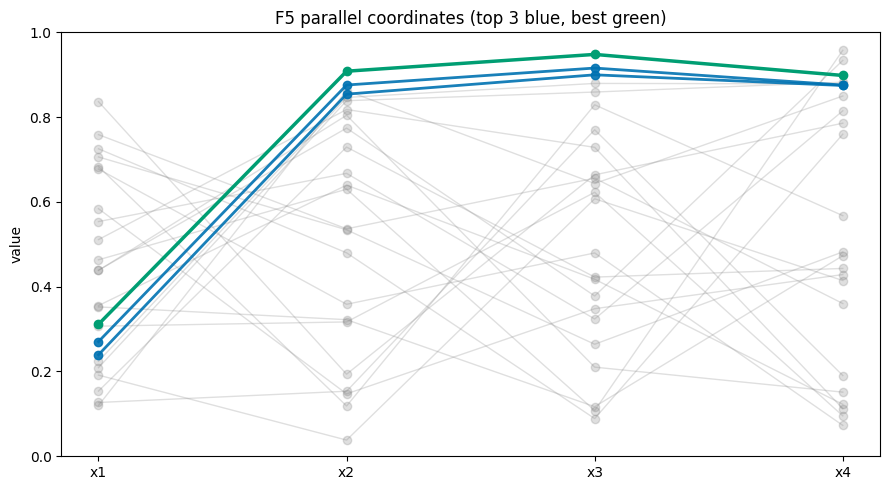

In [29]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}'); ax.set_title(f'x{d+1}: top vs bottom Y')
plt.suptitle('F5 — per-dimension exploration', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_5_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F5 parallel coordinates (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_05/function_5_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [30]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.023         0.041   -79.7%    0.082    0.393
  x2      0.201         0.209    -4.0%    0.229    0.578
  x3      0.655         0.627    +4.3%    0.401    0.644
  x4      0.121         0.123    -1.6%    0.288    0.616


In [31]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.2f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.2f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m5, nn_meta5 = nm.load_nn(5, models_dir='../models/week_05')
impr = (nn_meta5['baseline_rmse'] - nn_meta5['cv_rmse']) / nn_meta5['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta5['cv_rmse']:>10.2f}  {impr:>+6.1f}%  {'✓' if nn_meta5['beats_baseline'] else '✗'}  ({nn_meta5['variant']}/H{nn_meta5['hidden']})")
if nn_meta5['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m5, nn_meta5), nn_meta5['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      317.94   +40.8%  ✓
       KNN      202.22   +62.3%  ✓


        RF      237.17   +55.8%  ✓
       SVR      408.06   +24.0%  ✓


        GB      237.29   +55.8%  ✓


 GP-Matern      174.37   +67.5%  ✓


    GP-RBF      274.55   +48.8%  ✓
        NN      121.39   +77.4%  ✓  (plain/H32)

Models beating baseline: 8


In [32]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>40}  {'pred Y':>10}  boundary?")
print('-' * 75)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+10.2f}  {'BOUNDARY' if boundary else ''}")

non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus check:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

valid_p = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_p = np.array([v['pt'] for v in valid_p.values()]); names_p = list(valid_p.keys())
centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_p, distances) if d > threshold]
valid = {n: v for n, v in valid_p.items() if n not in excluded}
if excluded: print(f"\nOutlier suggestions excluded: {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

top4 = np.argsort(-Y)[:4]; top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
centroid_top4 = top4_X.T @ (shifted/shifted.sum())
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed: hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]: hybrid_query[d] = ensemble_mean[d]

print(f"\nValid (interior, non-Ridge, non-outlier): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'boundary-consensus' if i in boundary_informed else ('ensemble' if strong_mask[i] else 'centroid-top4')
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")

print(f"\nEnsemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"Hybrid:   ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"\nDominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.2f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.2f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m5, nn_meta5, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.0f}" for i in range(D)))
print(f"\nDistance from current best: ensemble={np.linalg.norm(ensemble_mean - X[best_i]):.4f}")


     Model                                suggestion      pred Y  boundary?
---------------------------------------------------------------------------
     Ridge  (0.0019, 0.9584, 0.9720, 0.9888)    +1348.84  BOUNDARY
       KNN  (0.3044, 0.9178, 0.9569, 0.9197)    +1841.13  


        RF  (0.3459, 0.9036, 0.9508, 0.9784)    +1791.42  
       SVR  (0.2501, 0.8663, 0.9505, 0.9325)     +596.84  


        GB  (0.4399, 0.9133, 0.9429, 0.9371)    +1982.91  
 GP-Matern  (0.3500, 0.9645, 0.9943, 0.9087)    +2175.48  BOUNDARY
    GP-RBF  (0.3044, 0.9178, 0.9569, 0.9197)    +2080.42  
        NN  (0.8943, 0.9958, 0.9760, 0.9970)    +4031.75  BOUNDARY

Boundary-consensus check:
  x1: low=0 high=0 r=-0.393 → no consensus
  x2: low=0 high=1 r=+0.578 → no consensus
  x3: low=0 high=1 r=+0.644 → no consensus
  x4: low=0 high=1 r=+0.616 → no consensus

Valid (interior, non-Ridge, non-outlier): ['KNN', 'RF', 'SVR', 'GB', 'GP-RBF']
  x1: spread=0.190 (STRONG) → ensemble: 0.3359
  x2: spread=0.052 (STRONG) → ensemble: 0.9073
  x3: spread=0.014 (STRONG) → ensemble: 0.9518
  x4: spread=0.059 (STRONG) → ensemble: 0.9378

Ensemble: (0.3359, 0.9073, 0.9518, 0.9378)
Hybrid:   (0.3359, 0.9073, 0.9518, 0.9378)

Dominance: KNN RMSE=202.22 vs RF RMSE=237.17  ratio=1.17x

NN dY/dx at best: dx1=+4350  dx2=+3058  dx3=+6065  dx4=+5063

Distance from current best: ensemble=0.0467


### Cell G — F5 Decision

**Decision tree branch: #5** (STRONG consensus on all 4 dims, no dominant model).

**Trajectory:** F5 has climbed every week — W1 988 → W2 1207 → W3 1412 → W4 1979. Ensemble approach has been calibrated for 4 weeks straight, with the W4 jump (+47%) far exceeding model predictions. The function appears to have plenty of room left.

**This week (24 pts):**
- All 8 families beat baseline. NN best at +77.4%, GP-Matern +67.5%, KNN +62.3%
- 3 models excluded for boundary: Ridge, GP-Matern (x3=0.99), NN (x1=0.89, x4=0.997)
- 5 valid interior models (KNN, RF, SVR, GB, GP-RBF) — STRONG consensus on all 4 dims
- KNN dominant 1.17× over RF — not dominant, ensemble wins

**Query:** ensemble ≈ (0.336, 0.907, 0.952, 0.938). **Distance from current best: 0.047** (similar to W4's 0.065).

**Per-dim sources:** all 4 from RMSE-weighted ensemble (STRONG everywhere). Direction: x1 +0.025 (continuing climb), x2 ~stable, x3 +0.004 (saturating near 0.95), x4 +0.040 (still climbing). NN gradient confirms all positive directions.

**Watch:** x3 at 0.952 is close to 0.98 boundary. GP-Matern wanted 0.994 (boundary-rejected). Next week may need to cap x3 around 0.96.

In [33]:
# Cell I — next_query_5 assignment [REQUIRED]
next_query_5 = ensemble_mean.copy()
print(f'F5 query: ({", ".join(f"{v:.6f}" for v in next_query_5)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (STRONG consensus all 4 dims)')
print(f'  distance from current best: {np.linalg.norm(next_query_5 - X[best_i]):.4f}')


F5 query: (0.335874, 0.907262, 0.951751, 0.937792)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'SVR', 'GB', 'GP-RBF'] (STRONG consensus all 4 dims)
  distance from current best: 0.0467


## Function 6

In [34]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(6)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()
print(f"F6: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W4 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 6: 24 points, 5D, best y = -0.3035
F6: 24 pts, 5D  |  Baseline=0.5772  |  Y range [-2.5712, -0.3035]
Per-dim correlations: r(x1,Y)=-0.065, r(x2,Y)=-0.419, r(x3,Y)=+0.222, r(x4,Y)=+0.612, r(x5,Y)=-0.680

Top 8 by Y (★=W4 query, *=current best):
  ★ #1  x=(0.4237, 0.4370, 0.5013, 0.8059, 0.0467)  y=-0.3035
    #2  x=(0.3870, 0.3734, 0.5139, 0.8531, 0.0470)  y=-0.3057
    #3  x=(0.5160, 0.3513, 0.5119, 0.6916, 0.1596)  y=-0.4370
    #4  x=(0.2838, 0.2587, 0.5077, 0.9687, 0.0439)  y=-0.6086
    #5  x=(0.7282, 0.1547, 0.7326, 0.6940, 0.0564)  y=-0.7143
    #6  x=(0.6188, 0.3318, 0.1873, 0.7562, 0.3288)  y=-0.8292
    #7  x=(0.7829, 0.5363, 0.4433, 0.8597, 0.0103)  y=-0.9358
    #8  x=(0.5368, 0.3088, 0.4119, 0.3882, 0.5225)  y=-1.1448


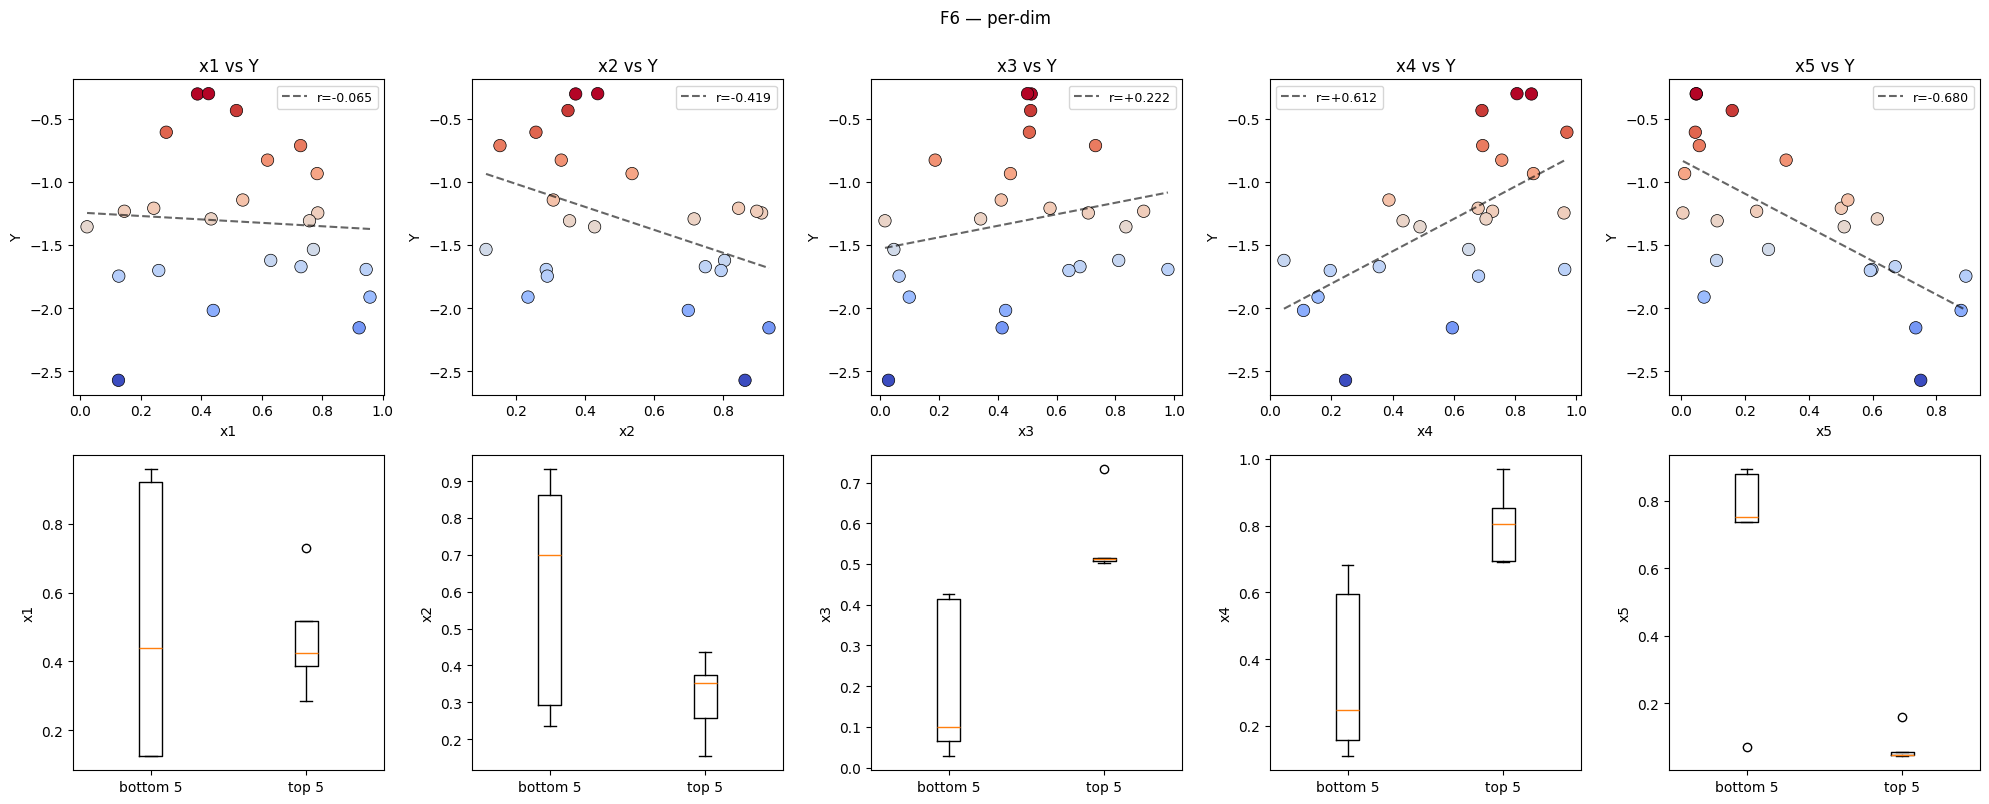

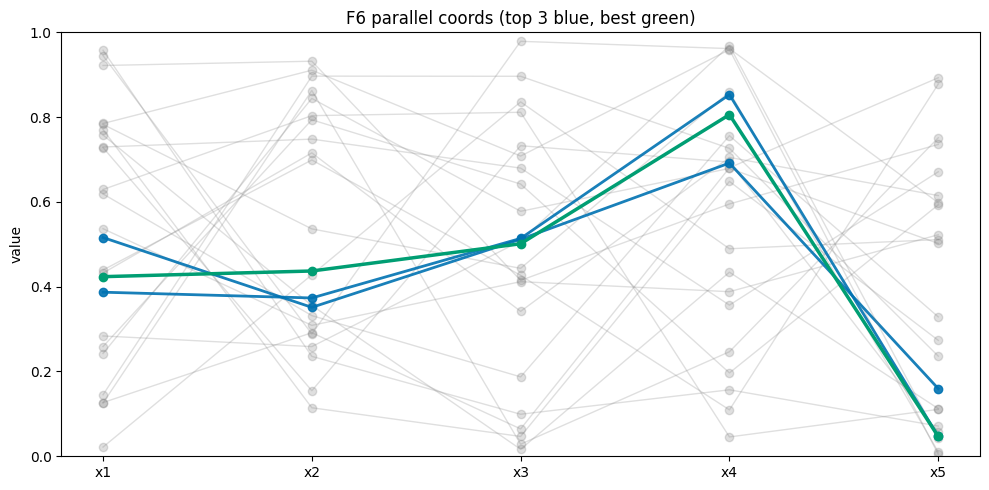

In [35]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(4*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=80, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=9); ax.set_title(f'x{d+1} vs Y')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bottom 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F6 — per-dim', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_6_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F6 parallel coords (top 3 blue, best green)')
plt.tight_layout(); plt.savefig('../plots/week_05/function_6_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [36]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.067         0.077   -13.4%    0.184    0.065
  x2      0.108         0.116    -7.4%    0.176    0.419
  x3      0.060         0.056    +7.4%    0.093    0.222
  x4      0.398         0.412    -3.5%    0.221    0.612
  x5      0.366         0.339    +7.3%    0.325    0.680


In [37]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m6, nn_meta6 = nm.load_nn(6, models_dir='../models/week_05')
impr = (nn_meta6['baseline_rmse'] - nn_meta6['cv_rmse']) / nn_meta6['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta6['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta6['beats_baseline'] else '✗'}  ({nn_meta6['variant']}/H{nn_meta6['hidden']})")
if nn_meta6['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m6, nn_meta6), nn_meta6['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.4035   +30.1%  ✓
       KNN      0.3827   +33.7%  ✓


        RF      0.3754   +35.0%  ✓
       SVR      0.2160   +62.6%  ✓


        GB      0.3524   +38.9%  ✓


 GP-Matern      0.2888   +50.0%  ✓


    GP-RBF      0.3315   +42.6%  ✓
        NN      0.3433   +40.5%  ✓  (ensemble/H32)

Models beating baseline: 8


In [38]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>50}  {'pred Y':>10}  boundary?")
print('-' * 80)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+10.4f}  {'BOUNDARY' if boundary else ''}")

non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus check:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

valid_p = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_p = np.array([v['pt'] for v in valid_p.values()]); names_p = list(valid_p.keys())
centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_p, distances) if d > threshold]
valid = {n: v for n, v in valid_p.items() if n not in excluded}
if excluded: print(f"\nOutlier suggestions excluded: {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

top4 = np.argsort(-Y)[:4]; top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
centroid_top4 = top4_X.T @ (shifted/shifted.sum())
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed: hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]: hybrid_query[d] = ensemble_mean[d]

print(f"\nValid (interior, non-Ridge, non-outlier): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'boundary-consensus' if i in boundary_informed else ('ensemble' if strong_mask[i] else 'centroid-top4')
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")

print(f"\nEnsemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"Hybrid:   ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"\nDominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m6, nn_meta6, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))
print(f"\nDistance from current best: ensemble={np.linalg.norm(ensemble_mean - X[best_i]):.4f}")


     Model                                          suggestion      pred Y  boundary?
--------------------------------------------------------------------------------
     Ridge  (0.0356, 0.0352, 0.9794, 0.9904, 0.0494)     -0.3942  BOUNDARY
       KNN  (0.4028, 0.4800, 0.4801, 0.7668, 0.0596)     -0.3274  


        RF  (0.4717, 0.3875, 0.6038, 0.8324, 0.0406)     -0.3899  
       SVR  (0.3783, 0.4271, 0.5800, 0.7148, 0.0050)     -0.3685  BOUNDARY


        GB  (0.4743, 0.4482, 0.5302, 0.7225, 0.0513)     -0.3214  
 GP-Matern  (0.3697, 0.4059, 0.5134, 0.7337, 0.0518)     -0.3088  
    GP-RBF  (0.4192, 0.4032, 0.4220, 0.8239, 0.0677)     -0.3119  
        NN  (0.0016, 0.0170, 0.2239, 0.0588, 0.0149)     +0.2426  BOUNDARY

Boundary-consensus check:
  x1: low=1 high=0 r=-0.065 → no consensus
  x2: low=1 high=0 r=-0.419 → no consensus
  x3: low=0 high=0 r=+0.222 → no consensus
  x4: low=0 high=0 r=+0.612 → no consensus
  x5: low=2 high=0 r=-0.680 → no consensus

Valid (interior, non-Ridge, non-outlier): ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF']
  x1: spread=0.105 (STRONG) → ensemble: 0.4248
  x2: spread=0.093 (STRONG) → ensemble: 0.4235
  x3: spread=0.182 (STRONG) → ensemble: 0.5083
  x4: spread=0.110 (STRONG) → ensemble: 0.7741
  x5: spread=0.027 (STRONG) → ensemble: 0.0543

Ensemble: (0.4248, 0.4235, 0.5083, 0.7741, 0.0543)
Hybrid:   (0.4248, 0.4235, 0.5083, 0.7741, 0.0543)

Dominance: GP-Matern RMSE=0.2888 vs GP-RBF RMSE=0.3315  r

### Cell G — F6 Decision

**Decision tree branch: #5** (STRONG consensus on all 5 dims).

**Trajectory:** F6 climbed W2(-0.44) → W3(-0.31) → W4(-0.30) — last week was marginal (+0.002), looking like plateau.

**This week (24 pts):**
- All 8 families beat baseline. SVR best at +62.6%, GP-Matern +50%, NN +40%
- Ridge, SVR, NN excluded as boundary (Ridge as usual; SVR's x5=0.005, NN's all 5 dims are sub-0.02)
- 5 valid interior models (KNN, RF, GB, GP-Matern, GP-RBF) — STRONG consensus on all 5 dims (max spread 0.18 on x3)
- GP-Matern dominant 1.15× — not dominant; ensemble is the right call

**Boundary-consensus check:** x5 has 2 non-Ridge models pushing < 0.02 (SVR + NN) with r=-0.68. Just 1 short of the ≥3 threshold. If a 3rd model agrees next week, x5 will get clipped.

**Query:** ensemble ≈ (0.425, 0.424, 0.508, 0.774, 0.054). **Distance from current best: 0.036** — small step matching the plateau pattern.

**Per-dim sources:** all 5 from RMSE-weighted ensemble. NN gradient: all negative (-0.41 to -0.88) — push everything DOWN. Ensemble does push x2/x4 down slightly, holds x5 low — direction-consistent.

**If W5 Y improves**: ensemble works for the plateau. **If similar**: try GP-Matern's pick as alternative direction. **If drops**: pull back closer to current best.

In [39]:
# Cell I — next_query_6 assignment [REQUIRED]
next_query_6 = ensemble_mean.copy()
print(f'F6 query: ({", ".join(f"{v:.6f}" for v in next_query_6)})')
print(f'  method: RMSE-weighted ensemble of {list(valid.keys())} (STRONG consensus all 5 dims)')
print(f'  distance from current best: {np.linalg.norm(next_query_6 - X[best_i]):.4f}')


F6 query: (0.424840, 0.423462, 0.508314, 0.774109, 0.054349)
  method: RMSE-weighted ensemble of ['KNN', 'RF', 'GB', 'GP-Matern', 'GP-RBF'] (STRONG consensus all 5 dims)
  distance from current best: 0.0361


## Function 7

In [40]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(7)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()
print(f"F7: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 8 by Y (★=W4, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:8]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.4f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 7: 34 points, 6D, best y = 1.4925
F7: 34 pts, 6D  |  Baseline=0.4447  |  Y range [0.0027, 1.4925]
Per-dim correlations: r(x1,Y)=-0.534, r(x2,Y)=+0.114, r(x3,Y)=+0.005, r(x4,Y)=-0.287, r(x5,Y)=-0.305, r(x6,Y)=+0.462

Top 8 by Y (★=W4, *=current best):
  ★ #1  x=(0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121)  y=+1.4925
    #2  x=(0.0354, 0.4803, 0.2600, 0.2068, 0.3732, 0.7752)  y=+1.4609
    #3  x=(0.0579, 0.4917, 0.2474, 0.2181, 0.4204, 0.7310)  y=+1.3650
    #4  x=(0.1291, 0.4626, 0.2670, 0.2370, 0.4030, 0.9000)  y=+1.1246
    #5  x=(0.0640, 0.4820, 0.2810, 0.1230, 0.4880, 0.6760)  y=+0.9318
    #6  x=(0.8816, 0.2045, 0.4145, 0.4204, 0.2649, 0.7307)  y=+0.6751
    #7  x=(0.1486, 0.0339, 0.7288, 0.3161, 0.0218, 0.5169)  y=+0.6115
    #8  x=(0.2726, 0.3245, 0.8971, 0.8330, 0.1541, 0.7959)  y=+0.6044


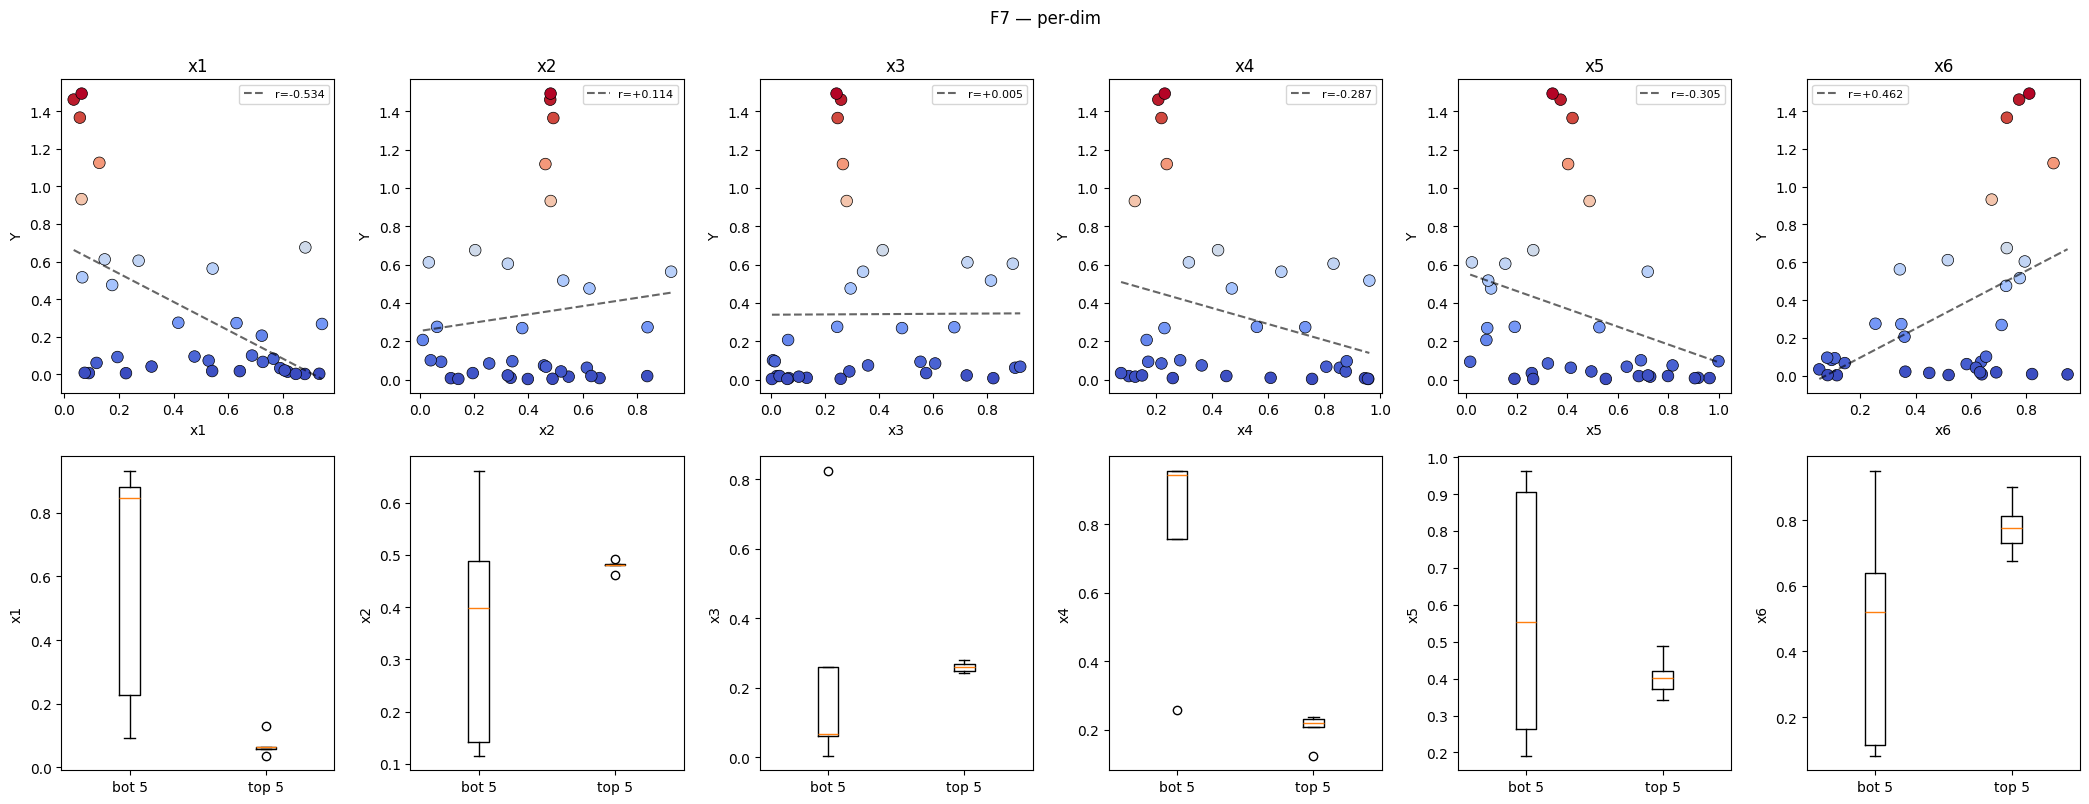

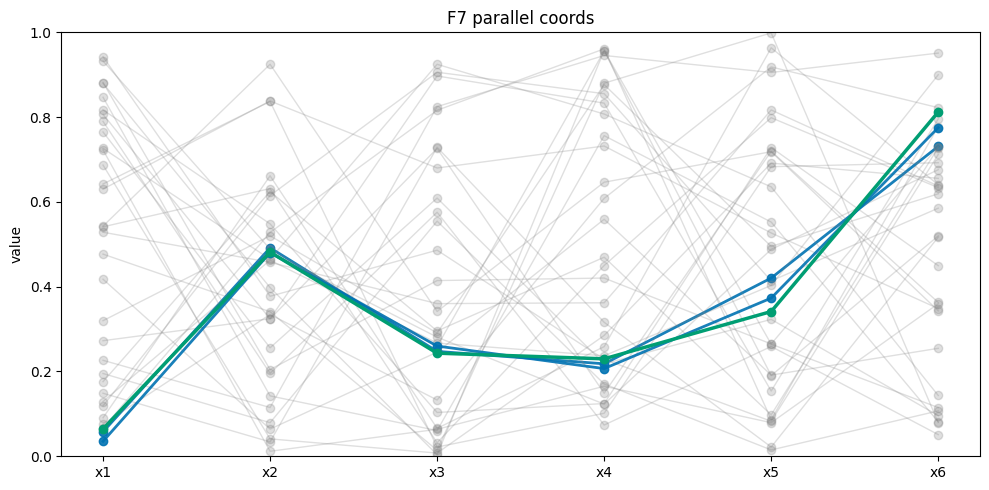

In [41]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(3.5*D, 8))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=70, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=8); ax.set_title(f'x{d+1}')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bot 5', 'top 5'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F7 — per-dim', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_7_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.25, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F7 parallel coords')
plt.tight_layout(); plt.savefig('../plots/week_05/function_7_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [42]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.640         0.563   +12.1%    0.252    0.534
  x2      0.051         0.059   -15.4%    0.122    0.114
  x3      0.042         0.046    -9.4%    0.062    0.005
  x4      0.032         0.050   -59.3%    0.149    0.287
  x5      0.089         0.110   -23.5%    0.250    0.305
  x6      0.146         0.171   -17.8%    0.165    0.462


In [43]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m7, nn_meta7 = nm.load_nn(7, models_dir='../models/week_05')
impr = (nn_meta7['baseline_rmse'] - nn_meta7['cv_rmse']) / nn_meta7['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta7['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta7['beats_baseline'] else '✗'}  ({nn_meta7['variant']}/H{nn_meta7['hidden']})")
if nn_meta7['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m7, nn_meta7), nn_meta7['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.3648   +18.0%  ✓
       KNN      0.2487   +44.1%  ✓


        RF      0.3285   +26.1%  ✓
       SVR      0.2395   +46.2%  ✓


        GB      0.3111   +30.0%  ✓


 GP-Matern      0.2206   +50.4%  ✓


    GP-RBF      0.2331   +47.6%  ✓
        NN      0.3239   +27.2%  ✓  (ensemble/H32)

Models beating baseline: 8


In [44]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>60}  {'pred Y':>10}  boundary?")
print('-' * 90)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.4f}' for v in pt)})  {pred.max():>+10.4f}  {'BOUNDARY' if boundary else ''}")

non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus check:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

valid_p = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
pts_p = np.array([v['pt'] for v in valid_p.values()]); names_p = list(valid_p.keys())
centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
threshold = distances.mean() + 2 * distances.std()
excluded = [n for n, d in zip(names_p, distances) if d > threshold]
valid = {n: v for n, v in valid_p.items() if n not in excluded}
if excluded: print(f"\nOutlier suggestions excluded: {excluded}")

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

top4 = np.argsort(-Y)[:4]; top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
centroid_top4 = top4_X.T @ (shifted/shifted.sum())
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed: hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]: hybrid_query[d] = ensemble_mean[d]

print(f"\nValid (interior, non-Ridge, non-outlier): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'boundary-consensus' if i in boundary_informed else ('ensemble' if strong_mask[i] else 'centroid-top4')
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")

print(f"\nEnsemble: ({', '.join(f'{v:.4f}' for v in ensemble_mean)})")
print(f"Hybrid:   ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
print(f"\nDominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m7, nn_meta7, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))
print(f"\nDistance from current best: hybrid={np.linalg.norm(hybrid_query - X[best_i]):.4f}")


     Model                                                    suggestion      pred Y  boundary?
------------------------------------------------------------------------------------------
     Ridge  (0.0666, 0.8669, 0.4368, 0.0265, 0.0199, 0.9280)     +1.0163  BOUNDARY
       KNN  (0.0832, 0.5423, 0.2862, 0.2689, 0.3623, 0.7842)     +1.3369  


        RF  (0.0331, 0.3653, 0.1458, 0.2326, 0.3341, 0.9636)     +1.3786  
       SVR  (0.0225, 0.4155, 0.1077, 0.1186, 0.2853, 0.8268)     +1.5570  


        GB  (0.0563, 0.0169, 0.2449, 0.7989, 0.0563, 0.9845)     +1.0691  BOUNDARY
 GP-Matern  (0.0832, 0.5423, 0.2862, 0.2689, 0.3623, 0.7842)     +1.3816  
    GP-RBF  (0.0421, 0.4430, 0.2522, 0.1920, 0.2433, 0.7455)     +1.4251  
        NN  (0.0015, 0.0895, 0.3615, 0.5212, 0.0815, 0.9779)     +2.0349  BOUNDARY

Boundary-consensus check:
  x1: low=1 high=0 r=-0.534 → no consensus
  x2: low=1 high=0 r=+0.114 → no consensus
  x3: low=0 high=0 r=+0.005 → no consensus
  x4: low=0 high=0 r=-0.287 → no consensus
  x5: low=0 high=0 r=-0.305 → no consensus
  x6: low=0 high=1 r=+0.462 → no consensus

Valid (interior, non-Ridge, non-outlier): ['KNN', 'RF', 'SVR', 'GP-Matern', 'GP-RBF']
  x1: spread=0.061 (STRONG) → ensemble: 0.0542
  x2: spread=0.177 (STRONG) → ensemble: 0.4678
  x3: spread=0.178 (STRONG) → ensemble: 0.2205
  x4: spread=0.150 (STRONG) → ensemble: 0.2157
  x5: spread=0.119 (STRONG) → ensemble: 0.3166
  x6: spread=0.218 (moderate) → centroid-top4: 0.7794

Ensemble: (0.0542, 0.4

### Cell G — F7 Decision

**Decision tree branch: #5 — strong but disagreeing on x6** (STRONG on 5/6 dims, moderate on x6 spread 0.218).

**Trajectory:** F7 climbing slowly via hybrid. W2(1.125) → W3(1.365) → W4(1.461) → W5(1.493). Smaller gains each week.

**This week (34 pts):**
- All 8 families beat baseline. GP-Matern best at +50.4%, GP-RBF +47.6%, SVR +46.2%, KNN +44.1%
- Ridge, GB, NN excluded (boundary)
- 5 valid interior models with STRONG consensus on x1, x2, x3, x4, x5; moderate on x6 (spread 0.218)
- GP-Matern dominant only 1.06× — ensemble takes precedence

**Per-dim sources:**
- x1, x2, x3, x4, x5: RMSE-weighted ensemble (STRONG consensus)
- x6: Y-weighted top-4 centroid (moderate consensus, models disagree 0.74 vs 0.96)

**Continuation of W3-W4 winning pattern:** same hybrid method that climbed F7 four weeks running. The "weak dim" rotated from x2 (W4) to x6 (W5) but the principle holds.

**Distance from current best: 0.052** — similar magnitude to prior successful steps. NN gradient: dx1=-2.65 (push x1 down), dx5=-1.13 (push x5 down). Direction-consistent with ensemble (x5 from 0.341 → 0.317).

**If W5 Y > 1.493**: hybrid keeps working. **If similar**: try different x6 value (centroid says 0.78, ensemble says 0.81). **If drops**: pull back closer to current best.

In [45]:
# Cell I — next_query_7 assignment [REQUIRED]
next_query_7 = hybrid_query.copy()
print(f'F7 query: ({", ".join(f"{v:.6f}" for v in next_query_7)})')
strong_dims = [i+1 for i, s in enumerate(strong_mask) if s and i not in boundary_informed]
weak_dims = [i+1 for i, s in enumerate(strong_mask) if not s and i not in boundary_informed]
print(f'  method: hybrid — STRONG ensemble on dims {strong_dims}, top-4 centroid on dims {weak_dims}')
print(f'  distance from current best: {np.linalg.norm(next_query_7 - X[best_i]):.4f}')


F7 query: (0.054203, 0.467824, 0.220489, 0.215666, 0.316569, 0.779411)
  method: hybrid — STRONG ensemble on dims [1, 2, 3, 4, 5], top-4 centroid on dims [6]
  distance from current best: 0.0520


## Function 8

In [46]:
# Cell A — setup + data overview [REQUIRED]
X, Y = load_function(8)
D = X.shape[1]
baseline = Y.std()
best_i = Y.argmax()
print(f"F8: {len(Y)} pts, {D}D  |  Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print(f"Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print(f"\nTop 6 by Y (★=W4 query, *=current best):")
for rank, idx in enumerate(np.argsort(-Y)[:6]):
    mark = '★' if idx == len(Y)-1 else ('*' if idx == best_i else ' ')
    print(f"  {mark} #{rank+1}  x=({', '.join(f'{X[idx,j]:.3f}' for j in range(D))})  y={Y[idx]:+.4f}")


Function 8: 44 points, 8D, best y = 9.8651
F8: 44 pts, 8D  |  Baseline=1.0735  |  Y range [5.5922, 9.8651]
Per-dim correlations: r(x1,Y)=-0.685, r(x2,Y)=-0.324, r(x3,Y)=-0.706, r(x4,Y)=-0.203, r(x5,Y)=-0.123, r(x6,Y)=+0.213, r(x7,Y)=-0.407, r(x8,Y)=+0.169

Top 6 by Y (★=W4 query, *=current best):
  * #1  x=(0.191, 0.228, 0.078, 0.188, 0.510, 0.741, 0.224, 0.717)  y=+9.8651
  ★ #2  x=(0.086, 0.216, 0.023, 0.133, 0.501, 0.739, 0.150, 0.728)  y=+9.8518
    #3  x=(0.155, 0.196, 0.085, 0.247, 0.487, 0.748, 0.347, 0.751)  y=+9.8209
    #4  x=(0.142, 0.231, 0.110, 0.208, 0.507, 0.725, 0.408, 0.710)  y=+9.8041
    #5  x=(0.056, 0.066, 0.023, 0.039, 0.404, 0.801, 0.488, 0.893)  y=+9.5985
    #6  x=(0.193, 0.631, 0.417, 0.491, 0.796, 0.655, 0.276, 0.296)  y=+9.3443


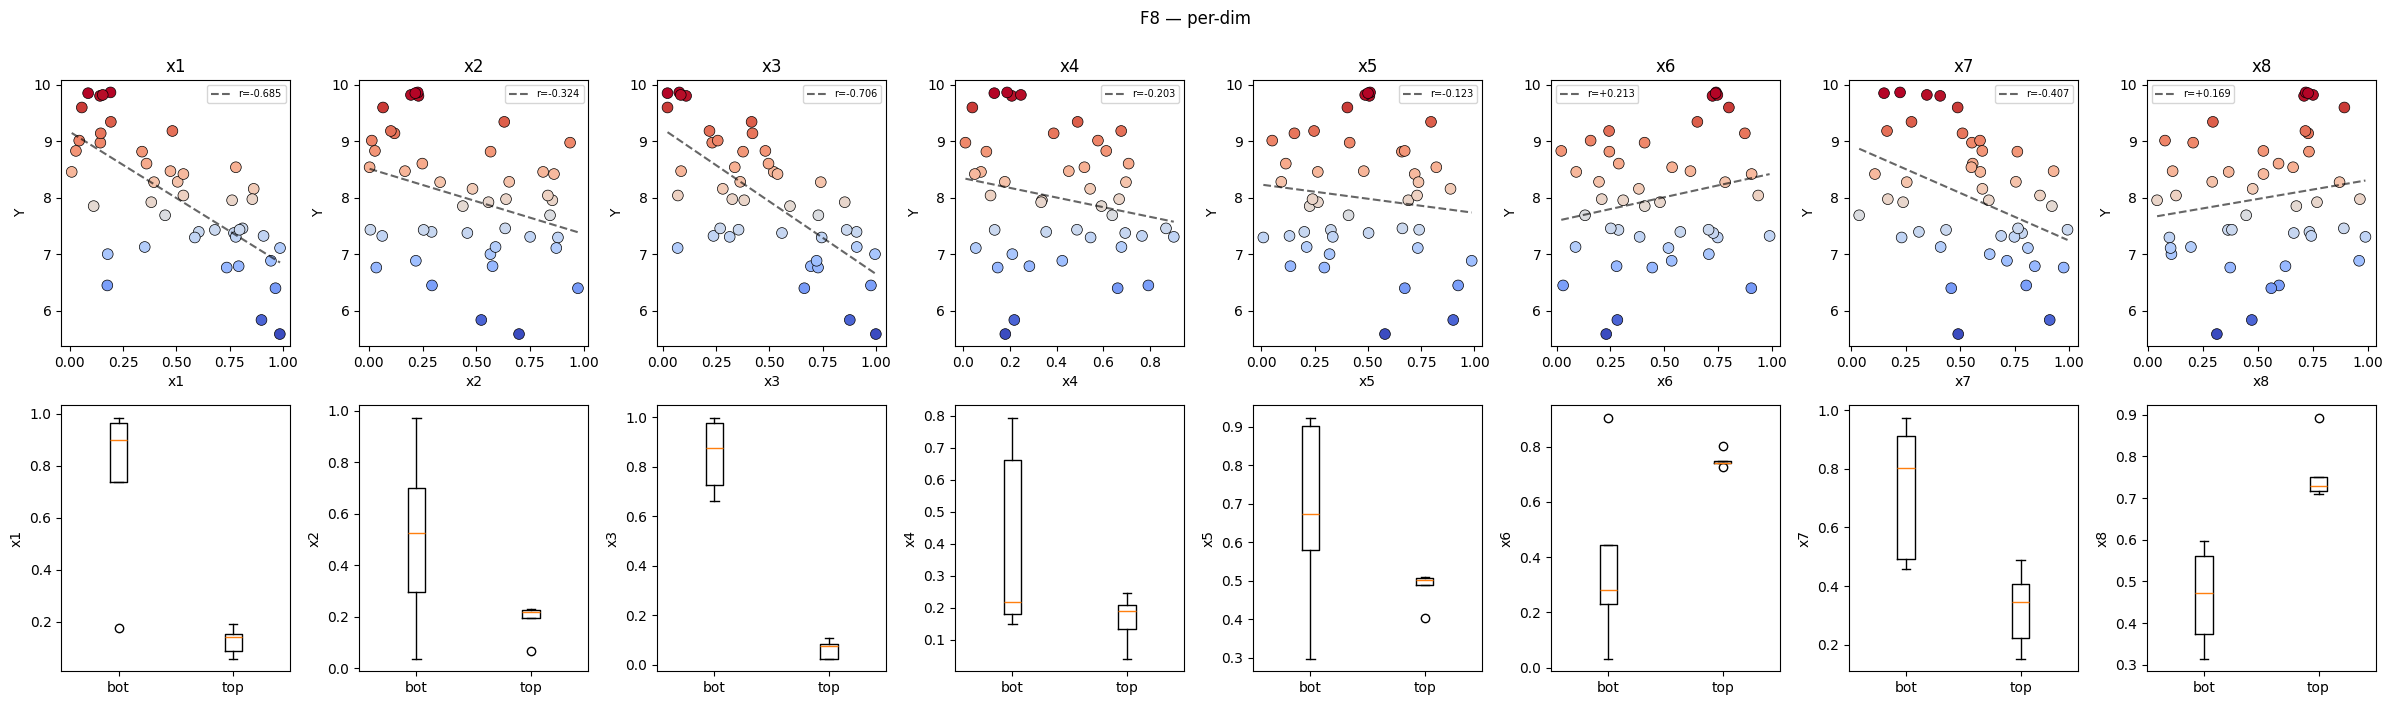

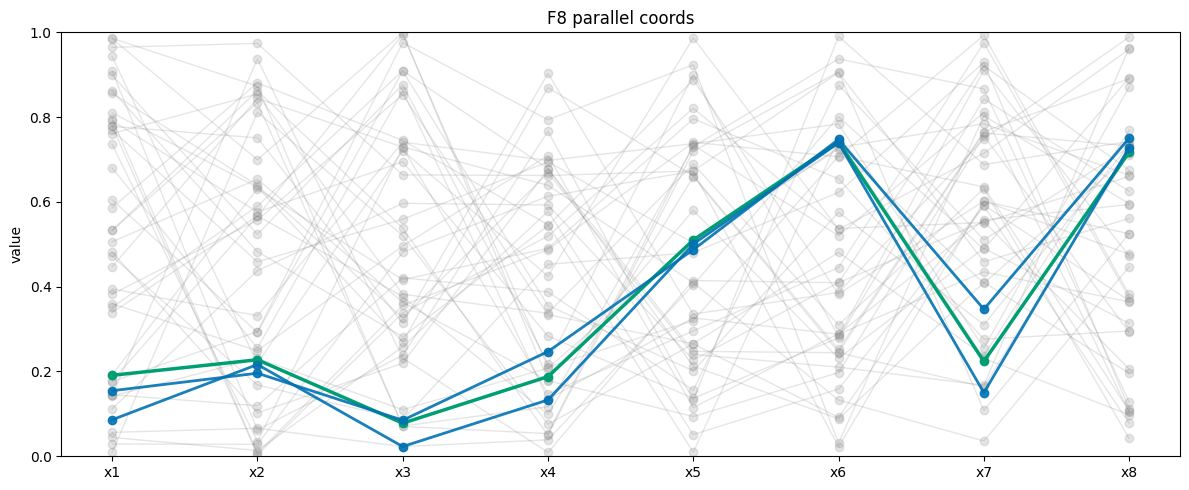

In [47]:
# Cell B — per-dim + parallel coords [REQUIRED]
fig, axes = plt.subplots(2, D, figsize=(3*D, 7))
order = np.argsort(Y); top5, bot5 = order[-5:], order[:5]
for d in range(D):
    r = np.corrcoef(X[:, d], Y)[0, 1]
    slope, intercept = np.polyfit(X[:, d], Y, 1)
    xs = np.linspace(X[:, d].min(), X[:, d].max(), 50)
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=60, edgecolors='black', linewidth=0.5)
    ax.plot(xs, slope*xs + intercept, color='black', linestyle='--', alpha=0.6, label=f'r={r:+.3f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=7); ax.set_title(f'x{d+1}')
    ax = axes[1, d]
    ax.boxplot([X[bot5, d], X[top5, d]], tick_labels=['bot', 'top'])
    ax.set_ylabel(f'x{d+1}')
plt.suptitle('F8 — per-dim', y=1.00); plt.tight_layout()
plt.savefig('../plots/week_05/function_8_per_dim.png', dpi=120, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
order_desc = np.argsort(-Y)
for i in range(len(Y)):
    color, alpha, lw = ('grey', 0.2, 1.0)
    if i == best_i: color, alpha, lw = (COLORS[2], 1.0, 2.5)
    elif i in order_desc[:3]: color, alpha, lw = (COLORS[0], 0.9, 2.0)
    ax.plot(range(D), X[i], color=color, alpha=alpha, linewidth=lw, marker='o')
ax.set_xticks(range(D)); ax.set_xticklabels([f'x{i+1}' for i in range(D)])
ax.set_ylabel('value'); ax.set_ylim(0, 1)
ax.set_title('F8 parallel coords')
plt.tight_layout(); plt.savefig('../plots/week_05/function_8_parallel.png', dpi=120, bbox_inches='tight'); plt.show()


In [48]:
# Cell C — feature importance robustness [REQUIRED]
rf_all    = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X, best_i, 0), np.delete(Y, best_i)).feature_importances_
lin_coef  = LinearRegression().fit(X, Y).coef_
lin_norm  = np.abs(lin_coef) / (np.abs(lin_coef).sum() + 1e-12)
corr_abs  = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(D)])
print(f"{'Dim':>4}  {'RF(all)':>8}  {'RF(no best)':>12}  {'drop%':>7}  {'|lin|':>7}  {'|corr|':>7}")
print('-' * 55)
for i in range(D):
    drop = (rf_all[i] - rf_nobest[i]) / (rf_all[i] + 1e-12) * 100
    flag = '  ← inflated!' if drop > 50 else ''
    print(f"  x{i+1}   {rf_all[i]:>8.3f}  {rf_nobest[i]:>12.3f}  {drop:>+6.1f}%  {lin_norm[i]:>7.3f}  {corr_abs[i]:>7.3f}{flag}")


 Dim   RF(all)   RF(no best)    drop%    |lin|   |corr|
-------------------------------------------------------
  x1      0.412         0.428    -3.8%    0.253    0.685
  x2      0.021         0.017   +18.7%    0.084    0.324
  x3      0.417         0.390    +6.5%    0.352    0.706
  x4      0.017         0.015   +12.0%    0.048    0.203
  x5      0.027         0.027    -1.0%    0.015    0.123
  x6      0.014         0.016   -12.6%    0.011    0.213
  x7      0.071         0.084   -18.5%    0.212    0.407
  x8      0.021         0.022    -9.4%    0.026    0.169


In [49]:
# Cell D — model grid search [REQUIRED]
families = {
    'Ridge': (Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}),
    'KNN':   (KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}),
    'RF':    (RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}),
    'SVR':   (SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}),
    'GB':    (GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1, 0.3]}),
}
beats_models = {}
print(f"{'Model':>10}  {'LOO RMSE':>10}  {'vs base':>8}  beats?")
print('-' * 45)
for name, (est, grid) in families.items():
    gs = GridSearchCV(est, grid, cv=loo, scoring='neg_mean_squared_error', refit=True).fit(X, Y)
    rmse = np.sqrt(-gs.best_score_)
    print(f"{name:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline: beats_models[name] = (gs.best_estimator_, rmse)
for kname, kern in [('GP-Matern', C(1.0)*Matern(0.3, nu=2.5)), ('GP-RBF', C(1.0)*RBF(0.3))]:
    gp = GaussianProcessRegressor(kernel=kern, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True, random_state=0)
    rmse = np.sqrt(-cross_val_score(gp, X, Y, cv=loo, scoring='neg_mean_squared_error').mean())
    print(f"{kname:>10}  {rmse:>10.4f}  {(baseline-rmse)/baseline*100:>+6.1f}%  {'✓' if rmse < baseline else '✗'}")
    if rmse < baseline:
        gp.fit(X, Y); beats_models[kname] = (gp, rmse)
nn_m8, nn_meta8 = nm.load_nn(8, models_dir='../models/week_05')
impr = (nn_meta8['baseline_rmse'] - nn_meta8['cv_rmse']) / nn_meta8['baseline_rmse'] * 100
print(f"{'NN':>10}  {nn_meta8['cv_rmse']:>10.4f}  {impr:>+6.1f}%  {'✓' if nn_meta8['beats_baseline'] else '✗'}  ({nn_meta8['variant']}/H{nn_meta8['hidden']})")
if nn_meta8['beats_baseline']:
    class NNWrap:
        def __init__(self, m, meta): self.m = m; self.meta = meta
        def predict(self, X): return nm.predict(self.m, self.meta, X)
    beats_models['NN'] = (NNWrap(nn_m8, nn_meta8), nn_meta8['cv_rmse'])
print(f"\nModels beating baseline: {len(beats_models)}")


     Model    LOO RMSE   vs base  beats?
---------------------------------------------
     Ridge      0.3865   +64.0%  ✓
       KNN      0.6009   +44.0%  ✓


        RF      0.4255   +60.4%  ✓
       SVR      0.2221   +79.3%  ✓


        GB      0.3932   +63.4%  ✓


 GP-Matern      0.1718   +84.0%  ✓


    GP-RBF      0.2205   +79.5%  ✓
        NN      0.3980   +62.9%  ✓  (plain/H32)

Models beating baseline: 8


In [50]:
# Cell E — model suggestions + convergence + boundary-consensus [CONDITIONAL]
np.random.seed(0)
cand = np.random.uniform(0, 1, (200000, D))
suggestions = {}
print(f"{'Model':>10}  {'suggestion':>70}  {'pred Y':>10}  boundary?")
print('-' * 100)
for name, (m, rmse) in beats_models.items():
    pred = m.predict(cand)
    pt = cand[pred.argmax()]
    boundary = (pt < 0.02).any() or (pt > 0.98).any()
    suggestions[name] = {'pt': pt, 'pred': pred.max(), 'rmse': rmse, 'boundary': boundary}
    print(f"{name:>10}  ({', '.join(f'{v:.3f}' for v in pt)})  {pred.max():>+10.4f}  {'BOUNDARY' if boundary else ''}")

non_ridge = {k: v for k, v in suggestions.items() if k != 'Ridge'}
top5_idx = np.argsort(-Y)[:5]
boundary_informed = {}
print(f"\nBoundary-consensus check:")
for d in range(D):
    low = sum(1 for v in non_ridge.values() if v['pt'][d] < 0.02)
    high = sum(1 for v in non_ridge.values() if v['pt'][d] > 0.98)
    r = np.corrcoef(X[:,d], Y)[0,1]
    if low >= 3 and r < -0.3:
        v = X[top5_idx, d].min(); boundary_informed[d] = v
        print(f"  x{d+1}: {low} models<0.02, r={r:+.3f} → CLIP to {v:.3f}")
    elif high >= 3 and r > 0.3:
        v = X[top5_idx, d].max(); boundary_informed[d] = v
        print(f"  x{d+1}: {high} models>0.98, r={r:+.3f} → CLIP to {v:.3f}")
    else:
        print(f"  x{d+1}: low={low} high={high} r={r:+.3f} → no consensus")

valid_p = {k: v for k, v in suggestions.items() if k != 'Ridge' and not v['boundary']}
print(f"\nInterior models: {list(valid_p.keys())}")
pts_p = np.array([v['pt'] for v in valid_p.values()]); names_p = list(valid_p.keys())
if len(pts_p) >= 3:
    centroid_s = pts_p.mean(axis=0); distances = np.linalg.norm(pts_p - centroid_s, axis=1)
    threshold = distances.mean() + 2 * distances.std()
    excluded = [n for n, d in zip(names_p, distances) if d > threshold]
    valid = {n: v for n, v in valid_p.items() if n not in excluded}
    if excluded: print(f"Outlier suggestions excl: {excluded}")
else:
    valid = valid_p

pts = np.array([v['pt'] for v in valid.values()])
rmses = np.array([v['rmse'] for v in valid.values()])
spread = pts.max(axis=0) - pts.min(axis=0)
w = 1/rmses; w /= w.sum()
ensemble_mean = pts.T @ w

top4 = np.argsort(-Y)[:4]; top4_X, top4_Y = X[top4], Y[top4]
shifted = top4_Y - top4_Y.min() + 0.01
centroid_top4 = top4_X.T @ (shifted/shifted.sum())
strong_mask = spread < 0.2
hybrid_query = centroid_top4.copy()
for d in range(D):
    if d in boundary_informed: hybrid_query[d] = boundary_informed[d]
    elif strong_mask[d]: hybrid_query[d] = ensemble_mean[d]

print(f"\nValid (interior, non-Ridge, non-outlier): {list(valid.keys())}")
for i in range(D):
    lbl = 'STRONG' if spread[i] < 0.2 else 'moderate' if spread[i] < 0.4 else 'weak'
    src_ = 'boundary-consensus' if i in boundary_informed else ('ensemble' if strong_mask[i] else 'centroid-top4')
    print(f"  x{i+1}: spread={spread[i]:.3f} ({lbl}) → {src_}: {hybrid_query[i]:.4f}")

print(f"\nHybrid: ({', '.join(f'{v:.4f}' for v in hybrid_query)})")

if len(valid) >= 2:
    sorted_rmses = sorted([(v['rmse'], k) for k, v in valid.items()])
    ratio = sorted_rmses[1][0] / sorted_rmses[0][0]
    print(f"\nDominance: {sorted_rmses[0][1]} RMSE={sorted_rmses[0][0]:.4f} vs {sorted_rmses[1][1]} RMSE={sorted_rmses[1][0]:.4f}  ratio={ratio:.2f}x")

grad = nm.gradient_at(nn_m8, nn_meta8, X[best_i])
print(f"\nNN dY/dx at best: " + "  ".join(f"dx{i+1}={grad[i]:+.2f}" for i in range(D)))
print(f"\nDistance from current best: hybrid={np.linalg.norm(hybrid_query - X[best_i]):.4f}")


     Model                                                              suggestion      pred Y  boundary?
----------------------------------------------------------------------------------------------------
     Ridge  (0.000, 0.141, 0.002, 0.028, 0.855, 0.382, 0.076, 0.421)    +10.6486  BOUNDARY
       KNN  (0.211, 0.195, 0.010, 0.162, 0.472, 0.735, 0.217, 0.673)     +9.8225  BOUNDARY


        RF  (0.161, 0.148, 0.082, 0.122, 0.150, 0.689, 0.023, 0.970)     +9.7575  
       SVR  (0.064, 0.361, 0.046, 0.188, 0.533, 0.327, 0.208, 0.467)    +10.1518  


        GB  (0.074, 0.184, 0.084, 0.469, 0.836, 0.778, 0.073, 0.740)     +9.8142  
 GP-Matern  (0.075, 0.270, 0.031, 0.350, 0.735, 0.442, 0.210, 0.332)     +9.9563  
    GP-RBF  (0.155, 0.142, 0.077, 0.003, 0.751, 0.155, 0.051, 0.703)    +10.0625  BOUNDARY
        NN  (0.467, 0.126, 0.255, 0.040, 0.902, 0.760, 0.001, 0.255)    +10.5668  BOUNDARY

Boundary-consensus check:
  x1: low=0 high=0 r=-0.685 → no consensus
  x2: low=0 high=0 r=-0.324 → no consensus
  x3: low=1 high=0 r=-0.706 → no consensus
  x4: low=1 high=0 r=-0.203 → no consensus
  x5: low=0 high=0 r=-0.123 → no consensus
  x6: low=0 high=0 r=+0.213 → no consensus
  x7: low=1 high=0 r=-0.407 → no consensus
  x8: low=0 high=0 r=+0.169 → no consensus

Interior models: ['RF', 'SVR', 'GB', 'GP-Matern']

Valid (interior, non-Ridge, non-outlier): ['RF', 'SVR', 'GB', 'GP-Matern']
  x1: spread=0.097 (STRONG) → ensemble: 0.0848
  x2: spread=0.213 (moderate) → centroid-top4: 0.2188
  x3: spread=0.053 (STRONG) → ensemble: 0.0519
  x4: 

### Cell G — F8 Decision

**Decision tree branch: #5 — strong but disagreeing on multiple dims** (STRONG on 3 dims, moderate on 2, weak on 3).

**W4 result:** boundary-consensus on x3 (clipped to 0.023) returned Y=9.85, slight regression from 9.87. The aggressive low-x3 push didn't pay off. Best is still W2's pick at (0.191, 0.228, 0.078, 0.188, 0.510, 0.741, 0.224, 0.717) Y=9.87.

**This week (44 pts):**
- All 8 families beat baseline. GP-Matern best at +84%, SVR/GP-RBF +79%, NN +63%
- 4 models excluded as boundary: Ridge, KNN (x3=0.010), GP-RBF (x4=0.003), NN (x7=0.001)
- Only 4 valid interior models (RF, SVR, GB, GP-Matern)
- GP-Matern dominant 1.29× — comparable, not dominant

**Boundary-consensus check on x3:** dropped from 4 non-Ridge models pushing low (W4) to only 1 (W5) — the addition of pt with x3=0.023 may have shifted models' confidence. No override this week.

**Per-dim sources:**
- x1, x3, x7: STRONG ensemble
- x2, x4: moderate → centroid-top4
- x5, x6, x8: weak → centroid-top4

**Distance from current best: 0.129** — moderate step, mostly via x1 reduction (0.191→0.085) and x7 reduction (0.224→0.158). Both are STRONG-consensus moves.

**NN gradient:** dx5=+0.99 strongest (push x5 up), dx3=+0.55, dx6=+0.35. Ensemble actually pushes x5 stable, x3 down — partial disagreement with NN, but NN's accuracy is below GP-Matern's so deferring.

In [51]:
# Cell I — next_query_8 assignment [REQUIRED]
next_query_8 = hybrid_query.copy()
print(f'F8 query: ({", ".join(f"{v:.6f}" for v in next_query_8)})')
strong_dims = [i+1 for i, s in enumerate(strong_mask) if s and i not in boundary_informed]
weak_dims   = [i+1 for i, s in enumerate(strong_mask) if not s and i not in boundary_informed]
bdry_dims   = [i+1 for i in range(D) if i in boundary_informed]
print(f'  method: hybrid — STRONG ensemble on dims {strong_dims}, top-4 centroid on dims {weak_dims}, boundary-consensus on {bdry_dims}')
print(f'  distance from current best: {np.linalg.norm(next_query_8 - X[best_i]):.4f}')


F8 query: (0.084770, 0.218794, 0.051901, 0.179535, 0.502886, 0.740713, 0.157593, 0.726102)
  method: hybrid — STRONG ensemble on dims [1, 3, 7], top-4 centroid on dims [2, 4, 5, 6, 8], boundary-consensus on []
  distance from current best: 0.1289


## Summary — Week 05 Queries

In [52]:
# === FINAL: All decided queries for F1–F8 ===
# References next_query_N from each function's analysis cell.
# Run the full notebook top-to-bottom to populate all values.

queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 05 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 05 — All queries for submission:
  Function 1: 0.228696-0.565819
  Function 2: 0.693851-0.962584
  Function 3: 0.514480-0.546868-0.340101
  Function 4: 0.367519-0.400462-0.395157-0.408596
  Function 5: 0.335874-0.907262-0.951751-0.937792
  Function 6: 0.424840-0.423462-0.508314-0.774109-0.054349
  Function 7: 0.054203-0.467824-0.220489-0.215666-0.316569-0.779411
  Function 8: 0.084770-0.218794-0.051901-0.179535-0.502886-0.740713-0.157593-0.726102
